# Supplementary Reading: Additional Techniques for the S2 2026 Assignment

*Data Science Applications*

**Required reading.** This Supplementary Reading is required reading for this assignment.

This document provides supplementary material on ten techniques and concepts that extend the content covered in Chapters 5--8 of the DSA textbook. Each section is self-contained and can be read alongside the relevant chapter. The techniques covered here are used in the S2 2026 assignment and are not covered, or only partially covered, in the main textbook.

---

**Table of contents**

Each entry names the assignment question the section is written for. Read at least the sections listed against the questions you are working on.

- [S1. Silhouette scores](#S1) — Q2a: choosing $K$ and evidencing cluster quality.
- [S2. Ridge regression and regularised linear models](#S2) — Q3b: a model family suited to wide, correlated text features.
- [S3. Regression evaluation metrics](#S3) — Q3b: out-of-sample metrics and evidence of practical discriminatory power. The same metrics are reported in Q3c and Q3d.
- [S4. Ablation analysis](#S4) — Q3b: the contribution of each feature group. Also Q4a(iii), which asks what the unavailable features cost.
- [S5. Stratified sampling](#S5) — Q1a: the seeded sample of classifications to audit. Also Q2c, for choosing what to inspect.
- [S6. Sentence embeddings](#S6) — Q1c: embeddings with dimensionality reduction, and what truncation does to a long 8-K filing.
- [S7. Domain-specific transformer models](#S7) — Q3a: one of the two required text representations. Also Q1c.
- [S8. Domain-specific sentiment lexicons](#S8) — Q3a: a second, contrasting text representation.
- [S9. Scenario analysis](#S9) — Q4a: scenario construction and reaction ranges. Also Q3c, on asymmetric predictability.
- [S10. Discriminator modelling](#S10) — Q2b: the technique that question names.
- [Appendix: Exercise answers](#appendix)

Q1b, Q1d, Q2d, Q3d, Q4b, Q4c and Q5 are answered from the textbook and the assignment brief; no section here is written for them.


In [1]:
import numpy as np, pandas as pd, matplotlib.pyplot as plt, seaborn as sns
import warnings
# Narrowed on purpose: a blanket filterwarnings('ignore') would also hide convergence,
# deprecation and data-quality warnings, which are the ones worth learning to read - and on
# Colab they are often the only clue that a library version has moved under you.
warnings.filterwarnings('ignore', category=FutureWarning)
plt.rcParams['figure.dpi'] = 120
plt.rcParams['figure.figsize'] = (8, 4)
plt.rcParams['font.size'] = 10
np.random.seed(42)


---
<a id="S1"></a>
## S1. Silhouette scores

*Extends Chapter 6, Section 6.3.5 (Validating clustering outcomes)*

**Supports Q2a** — choosing $K$ and evidencing cluster quality.

### Background

Chapter 6 introduces three internal validation measures for clustering: within-cluster sum of squares (WCSS), the Davies-Bouldin index, and the Dunn index. These measures evaluate clustering quality at the *global* level — they produce a single score summarising all clusters. In practice it is often useful to assess quality at the *observation* level, to identify which observations are well-clustered and which sit ambiguously between clusters. The **silhouette coefficient** scores each observation individually, and its average doubles as a global score.

What it measures is narrower than 'clustering quality', and the definition below makes the limit visible: every quantity in it is a mean pairwise distance. A compact, roughly spherical cluster scores well. A long, thin or curved cluster scores badly even when it is exactly the right cluster, because the average distance between its own members is large. The silhouette measures compactness and reports it as quality; 'Choosing $K$ using silhouette scores' below shows what that costs.

### Definition

The silhouette coefficient for observation $i$ is defined as:

$$s(i) = \frac{b(i) - a(i)}{\max\{a(i),\, b(i)\}} \tag{S1.1}$$

where:

- $a(i)$ is the **mean intra-cluster distance**: the average distance from observation $i$ to all other observations in the same cluster; and
- $b(i)$ is the **mean nearest-cluster distance**: the average distance from observation $i$ to all observations in the nearest neighbouring cluster (i.e. the cluster that minimises this average distance, excluding $i$'s own cluster).

The distance measure used in computing $a(i)$ and $b(i)$ should be consistent with the distance measure used in the clustering algorithm (e.g. Euclidean distance for k-means).

### Interpretation

The silhouette coefficient takes values in the range $[-1, +1]$:

- $s(i) \approx +1$: observation $i$ is well-matched to its own cluster and poorly matched to its nearest neighbouring cluster. This is the desirable outcome.
- $s(i) \approx 0$: observation $i$ lies approximately on the boundary between two clusters and could plausibly belong to either.
- $s(i) \approx -1$: observation $i$ is, on average, closer to observations in a neighbouring cluster than to observations in its own cluster. This suggests a potential misclassification.

The **mean silhouette score** across all observations provides a global measure of clustering quality:

$$\bar{s} = \frac{1}{n}\sum_{i=1}^{n} s(i) \tag{S1.2}$$

A higher mean silhouette score indicates better-defined clusters. As a rough guide:

| Range | Interpretation |
|-------|---------------|
| $\bar{s} > 0.70$ | Strong structure |
| $0.50 < \bar{s} \leq 0.70$ | Reasonable structure |
| $0.25 < \bar{s} \leq 0.50$ | Weak structure, possibly overlapping clusters |
| $\bar{s} \leq 0.25$ | Little meaningful structure detected |

These thresholds should be interpreted with caution. In high-dimensional data (e.g. text embeddings with 50+ dimensions), silhouette scores tend to be lower than in low-dimensional settings, even when clusters are genuinely meaningful. This is because distances become less discriminating in high dimensions — a phenomenon related to the curse of dimensionality discussed in Chapter 6, Section 6.2. In such settings, a silhouette score of 0.06--0.10 may still correspond to clusters that are useful for a business purpose, even though the score appears low in absolute terms.

### Choosing $K$ using silhouette scores

The silhouette score can be used to select the number of clusters, $K$, as an alternative to the elbow method described in Chapter 6, Section 6.3.2. The procedure is:

1. For each candidate value of $K$ (e.g. $K = 2, 3, \ldots, 15$), fit the clustering algorithm and compute $\bar{s}$.
2. Select the value of $K$ that maximises $\bar{s}$.

This approach has an operational advantage over the elbow method: it returns a number rather than requiring subjective identification of an 'elbow' in a plot. The number is less arguable, which is not the same as being more reliable.

The two interlocking crescents produced by `sklearn.datasets.make_moons` are the standard non-convex test case. On 1,000 points with `noise=0.05`, the correct labelling — one crescent per cluster — scores $\bar{s} = 0.33$, which the table above calls weak structure. Every k-means partition of the same points scores higher: 0.49 at $K = 2$, where each cluster takes about a quarter of its members from the other crescent, and 0.53 at $K = 9$, which the table calls reasonable structure; the sequence dips in between rather than climbing steadily. Maximising $\bar{s}$ over $K$ here does not merely miss the right answer; it ranks the right answer below every alternative it was offered. Equation S1.1 shows why: $a(i)$ is the mean distance from $i$ to *every* other member of its cluster, so an elongated or curved cluster carries a large $a(i)$ by construction, whatever its members have in common. A low silhouette on data whose natural groups are long or density-defined is evidence about their shape, not about their validity. For example, a solution with $K = 3$ may have a higher silhouette score than $K = 8$, but $K = 8$ may produce more specialised clusters that are more informative for the task at hand. In practice, the silhouette score should be used alongside domain knowledge and business requirements when selecting $K$.

### Silhouette plots

A **silhouette plot** displays the silhouette coefficient for every observation, grouped by cluster and sorted in descending order within each cluster. This visualisation reveals:

- the overall quality of each cluster (the width of positive-valued bars);
- whether certain clusters are less well-defined than others (clusters with many observations near or below zero); and
- the relative size of each cluster.

Figure S1.1 shows an example silhouette plot for a dataset with four clusters.

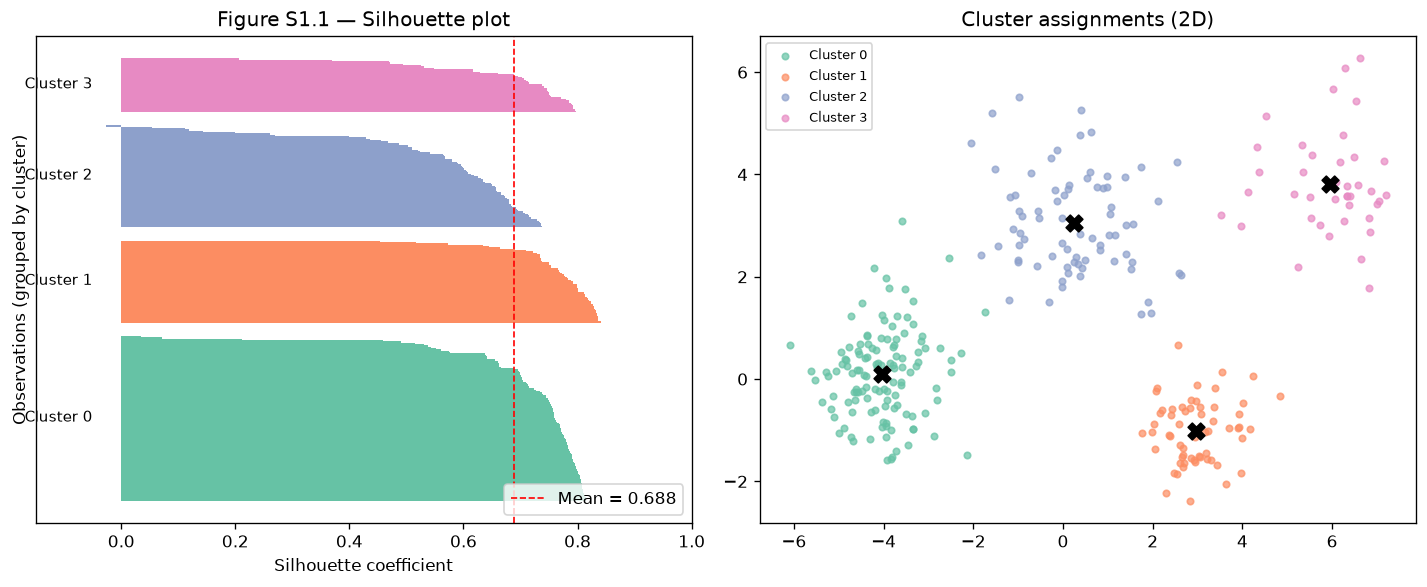

In [2]:
# Figure S1.1 — Silhouette plot (illustrative)
from sklearn.datasets import make_blobs
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, silhouette_samples

# Generate synthetic data with 4 clusters of different sizes and separations
X_demo, _ = make_blobs(n_samples=[120, 80, 60, 40], centers=[[-4,0],[0,3],[3,-1],[6,4]],
                        cluster_std=[0.8, 1.2, 0.6, 1.0], random_state=42)
km = KMeans(n_clusters=4, random_state=42, n_init=10).fit(X_demo)
labels = km.labels_
sil_vals = silhouette_samples(X_demo, labels)
mean_sil = silhouette_score(X_demo, labels)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left panel: silhouette plot
y_lower = 10
cmap = plt.colormaps['Set2']
for i in range(4):
    cluster_sil = np.sort(sil_vals[labels == i])[::-1]
    size_i = len(cluster_sil)
    y_upper = y_lower + size_i
    ax1.barh(range(y_lower, y_upper), cluster_sil, height=1.0, color=cmap(i), edgecolor='none')
    ax1.text(-0.05, y_lower + 0.5 * size_i, f'Cluster {i}', fontsize=9, va='center', ha='right')
    y_lower = y_upper + 10

ax1.axvline(x=mean_sil, color='red', linestyle='--', linewidth=1, label=f'Mean = {mean_sil:.3f}')
ax1.set_xlabel('Silhouette coefficient')
ax1.set_ylabel('Observations (grouped by cluster)')
ax1.set_yticks([])
ax1.set_title('Figure S1.1 — Silhouette plot')
ax1.legend(loc='lower right')
ax1.set_xlim([-0.15, 1.0])

# Right panel: the data in 2D
for i in range(4):
    ax2.scatter(X_demo[labels==i, 0], X_demo[labels==i, 1], c=[cmap(i)], s=15, alpha=0.7, label=f'Cluster {i}')
ax2.scatter(km.cluster_centers_[:, 0], km.cluster_centers_[:, 1], c='black', marker='X', s=100, zorder=5)
ax2.set_title('Cluster assignments (2D)')
ax2.legend(fontsize=8)
plt.tight_layout()
plt.show()

In a well-clustered solution, all bars should extend well to the right of zero, and the clusters should be of roughly similar size. A cluster where many observations have silhouette scores near zero or negative may warrant further investigation — it may represent a heterogeneous group that should be split, or it may contain observations that are better assigned to an adjacent cluster.

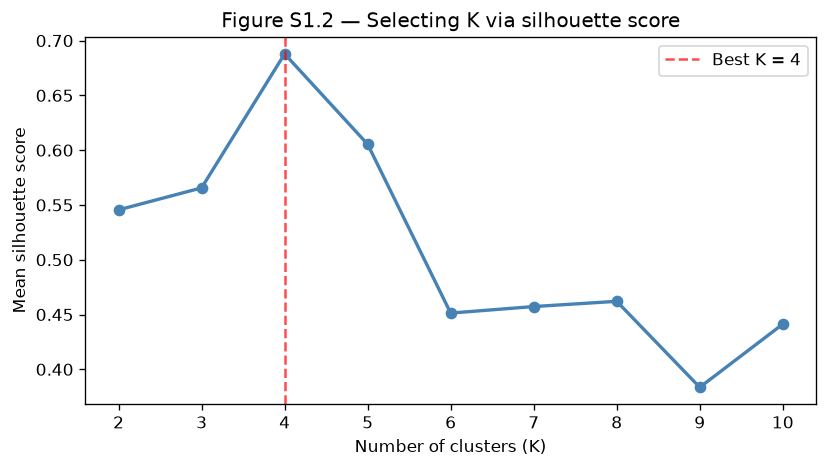

In [3]:
# Figure S1.2 — Silhouette score vs K
sil_scores = []
K_range = range(2, 11)
for k in K_range:
    km_k = KMeans(n_clusters=k, random_state=42, n_init=10).fit(X_demo)
    sil_scores.append(silhouette_score(X_demo, km_k.labels_))

fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(K_range, sil_scores, 'o-', color='steelblue', linewidth=2)
best_k = list(K_range)[np.argmax(sil_scores)]
ax.axvline(x=best_k, color='red', linestyle='--', alpha=0.7, label=f'Best K = {best_k}')
ax.set_xlabel('Number of clusters (K)')
ax.set_ylabel('Mean silhouette score')
ax.set_title('Figure S1.2 — Selecting K via silhouette score')
ax.legend()
ax.set_xticks(list(K_range))
plt.tight_layout()
plt.show()

### Implementation in Python

```python
from sklearn.metrics import silhouette_score, silhouette_samples

# Compute mean silhouette score
mean_sil = silhouette_score(X, cluster_labels, metric='euclidean')
print(f"Mean silhouette score: {mean_sil:.4f}")

# Compute per-observation silhouette scores (for silhouette plot)
sample_sil = silhouette_samples(X, cluster_labels, metric='euclidean')
```

The `silhouette_score` function in scikit-learn computes $\bar{s}$ as defined in Equation S1.2. The `silhouette_samples` function returns the silhouette coefficient $s(i)$ for each observation, which can be used to construct a silhouette plot.

### Combining feature blocks of different widths

A silhouette score is only as informative as the matrix the distances are computed on. Standardising each column to mean zero and unit variance equalises the scale of features, but not their number. When a reduced text representation — say 50 components of a TF-IDF or embedding matrix — is placed beside a handful of structured columns, say six trial characteristics, every column enters a Euclidean distance on equal terms, so the text block supplies roughly 50 of the 56 squared differences. Rescaling the columns does not change that: the text block still contributes most of the distance, and clusters found on the combined matrix will largely be text clusters wearing a structured-data costume. The silhouette score is then a statement about the text block rather than about the combination. Chapter 6, Section 6.3.1 gives the underlying principle — feature scaling prevents large features dominating a distance calculation — and Gower's distance allows per-feature weights. The point here is the extension of that principle from feature *magnitude* to feature count.

```python
from sklearn.preprocessing import StandardScaler
import numpy as np

X_struct_scaled = StandardScaler().fit_transform(X_struct)   # e.g. 6 columns
X_combined = np.hstack([X_text_reduced, X_struct_scaled])    # e.g. 50 + 6 columns
```

Three levers are available. Any of them is defensible, provided the choice is stated and the reason given:

- **Scale by block.** After standardising within each block, divide each block by the square root of its column count, so that the two blocks contribute comparable total variance to the distance.
- **Weight explicitly.** Multiply one block by a constant chosen for the business purpose, or use per-feature weights in Gower's distance (Chapter 6, Section 6.3.1).
- **Reduce further.** Cut the text block to fewer components so that its column count is closer to the structured block's.

There is no correct answer among the three. What matters is that the imbalance is recognised and the treatment recorded, because the choice determines what the resulting clusters are about.

> **Exercise S1.1** | Using the COVID-19 dataset from Exercise 6.4, fit k-means clustering for $K = 2, 3, \ldots, 10$. Compute the mean silhouette score for each value of $K$. Compare the $K$ selected by the silhouette method with the $K$ selected by the elbow method in Exercise 6.4. Discuss whether the two methods agree and, if not, which solution you would prefer for the purpose of grouping countries by their pandemic response.

> **Exercise S1.2** | For the $K$ selected in Exercise S1.1, construct a silhouette plot. Identify any clusters that appear poorly defined. Examine the observations with the lowest silhouette scores and discuss whether these observations represent genuine edge cases or potential misclassifications.

---
<a id="S2"></a>
## S2. Ridge regression and regularised linear models

*Extends Chapter 5, Section 5.3.1 (Logistic regression) and Section 5.5.5 (Practical considerations)*

**Supports Q3b** — a model family suited to wide, correlated text features.

### Background

Chapter 5 introduces regularisation in the context of neural networks (Section 5.5.5), where an L2 penalty term $\lambda \sum \theta_j^2$ is added to the loss function to shrink weights toward zero and reduce overfitting. Attaching that same penalty to an ordinary least squares (OLS) fit produces **ridge regression**. It buys one thing, stability: coefficients that stop swinging when the sample changes, and usually lower out-of-sample error where features are numerous or correlated. It does not buy a smaller model — ridge shrinks every coefficient and zeroes none — and it does not make a coefficient mean more than it did. If anything, stability makes coefficients easier to over-read; see "Correlated predictors" below.

### The problem with ordinary least squares

In ordinary least squares regression, the objective is to find the coefficients $\hat{\beta}$ that minimise the residual sum of squares:

$$\hat{\beta}_{OLS} = \underset{\beta}{\text{argmin}} \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2 \tag{S2.1}$$

When the number of features $p$ is large relative to the number of observations $n$, or when features are highly correlated (multicollinearity), OLS estimates become unstable: small changes in the data can produce large changes in the estimated coefficients. This instability leads to high variance in predictions, even though the model may fit the training data well.

This situation is common when working with text-derived features. For example, a TF-IDF matrix with thousands of columns applied to a dataset of a few thousand observations will often produce an OLS model that overfits the training data and generalises poorly.

### Ridge regression

Ridge regression addresses this by adding a penalty proportional to the sum of squared coefficients:

$$\hat{\beta}_{ridge} = \underset{\beta}{\text{argmin}} \left\{ \sum_{i=1}^{n} \left(y_i - \beta_0 - \sum_{j=1}^{p} \beta_j x_{ij}\right)^2 + \lambda \sum_{j=1}^{p} \beta_j^2 \right\} \tag{S2.2}$$

where $\lambda \geq 0$ is the **regularisation parameter** (also called the penalty strength or shrinkage parameter). Note that the intercept $\beta_0$ is typically excluded from the penalty term.

The effect of the penalty is to shrink all coefficients toward zero. The larger the value of $\lambda$, the greater the shrinkage. When $\lambda = 0$, ridge regression reduces to OLS. As $\lambda \to \infty$, all coefficients are shrunk to zero.

This is the same L2 penalty described in Chapter 5, Section 5.5.5, for neural network weights. The key insight is that by accepting a small increase in bias (from shrinking coefficients away from their OLS values), ridge regression achieves a potentially large reduction in variance, leading to better out-of-sample predictions. This is a direct application of the bias-variance trade-off discussed in Chapter 5, Section 5.4.1.

### Correlated predictors

Ridge never sets a coefficient to exactly zero, so every column you put in comes back out. A 5,000-column TF-IDF matrix produces a 5,000-coefficient model, and all 5,000 must be computed on every new observation you score. Ridge is a shrinkage method, not a selection method; lasso, below, is the one that removes columns.

Nor does ridge choose between correlated columns. It splits them. For two identical columns the fitted coefficient is divided equally between them, because for a fixed total the equal split is what minimises the sum of squares in the penalty; five identical columns take a fifth each, and the total is preserved. Duplicating a single column in a fitted example moves its coefficient from 2.997 to 1.500 and then to 0.600 across five copies — the column's influence is unchanged and its reported coefficient has fallen by four fifths. No single coefficient reports it. Near-duplicates behave the same way, less exactly.

With text features that is the ordinary case rather than a pathology. If one concept is spelled five ways across a TF-IDF matrix — terminated, discontinued, halted, wound down, stopped early — its effect is divided five ways, and each of the five will rank below any unrelated single column whose own effect exceeds a fifth of the concept's. A table of ridge coefficients sorted by magnitude therefore ranks columns, not the things the columns stand for. The coefficients are stable; they are not attributions. Ranking features by what they contribute is a separate exercise — ablation, Section S4 — and a stable coefficient is no substitute for it.

### Feature scaling

Because the penalty $\lambda \sum \beta_j^2$ treats all coefficients equally, features must be **standardised** before fitting a ridge regression model. If features are on different scales, the penalty will disproportionately shrink the coefficients of features with larger magnitudes, regardless of their predictive value.

Standardisation involves transforming each feature to have mean zero and unit variance:

$$\tilde{x}_{ij} = \frac{x_{ij} - \bar{x}_j}{\hat{\sigma}_j} \tag{S2.3}$$

where $\bar{x}_j$ and $\hat{\sigma}_j$ are the mean and standard deviation of feature $j$ in the training data. It is important that the standardisation parameters are computed from the training data only and then applied to both training and test data, to avoid data leakage (see Chapter 5, Section 5.2.5).

In Python, the `Pipeline` class from scikit-learn ensures that standardisation and model fitting are performed correctly within cross-validation:

```python
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import RidgeCV

pipe = Pipeline([
    ('scaler', StandardScaler()),
    ('ridge', RidgeCV(alphas=[0.01, 0.1, 1.0, 10.0, 100.0]))
])
pipe.fit(X_train, y_train)
```

Scale and count are different problems. An L2 penalty applies to each coefficient separately and the coefficients are still fitted to the response, so a wide text block competes for the penalty budget but does not dominate by column count alone. In a Euclidean distance it does, which is why unequal block widths are dealt with in [S1](#S1) rather than here.

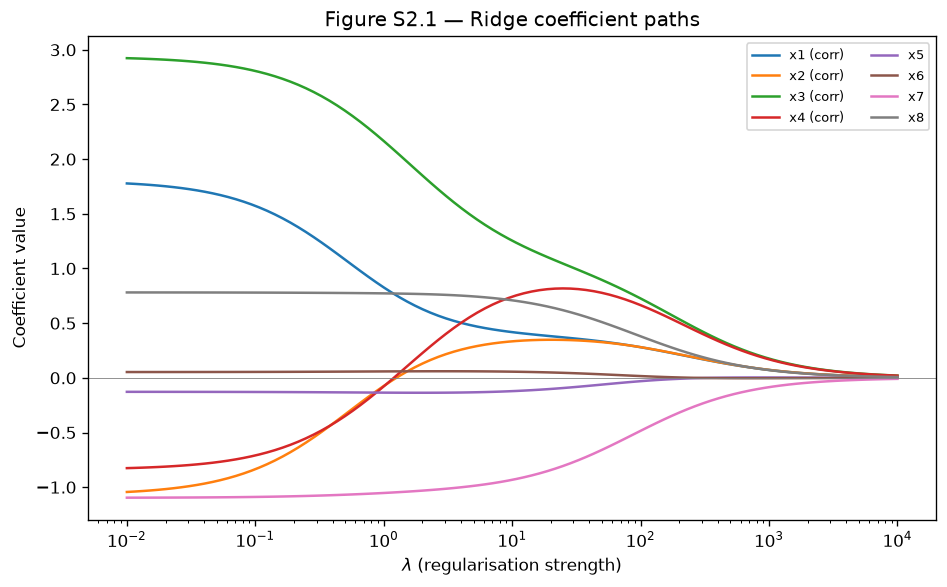

As lambda increases, all coefficients shrink toward zero.
Correlated features (beta_1/beta_2 and beta_3/beta_4) are affected first.


In [4]:
# Figure S2.1 — Ridge coefficient paths: how coefficients shrink as lambda increases
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler

# Synthetic regression data with correlated features
rng = np.random.RandomState(42)
n, p = 100, 8
X_ridge = rng.randn(n, p)
X_ridge[:, 1] = X_ridge[:, 0] + 0.1 * rng.randn(n)   # correlated pair
X_ridge[:, 3] = X_ridge[:, 2] + 0.2 * rng.randn(n)   # another correlated pair
true_beta = np.array([3, -2, 1.5, 0.5, 0, 0, -1, 0.8])
y_ridge = X_ridge @ true_beta + rng.randn(n) * 2

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_ridge)

alphas = np.logspace(-2, 4, 100)
coefs = []
for a in alphas:
    ridge = Ridge(alpha=a, fit_intercept=True)
    ridge.fit(X_scaled, y_ridge)
    coefs.append(ridge.coef_)
coefs = np.array(coefs)

fig, ax = plt.subplots(figsize=(8, 5))
feat_names = ['x1 (corr)', 'x2 (corr)', 'x3 (corr)', 'x4 (corr)', 'x5', 'x6', 'x7', 'x8']
for j in range(p):
    ax.plot(alphas, coefs[:, j], linewidth=1.5, label=feat_names[j])
ax.set_xscale('log')
ax.axhline(y=0, color='grey', linestyle='-', linewidth=0.5)
ax.set_xlabel('$\lambda$ (regularisation strength)')
ax.set_ylabel('Coefficient value')
ax.set_title('Figure S2.1 — Ridge coefficient paths')
ax.legend(fontsize=8, ncol=2, loc='upper right')
plt.tight_layout()
plt.show()
print("As lambda increases, all coefficients shrink toward zero.")
print("Correlated features (beta_1/beta_2 and beta_3/beta_4) are affected first.")

### Choosing $\lambda$ via cross-validation

The regularisation parameter $\lambda$ is a hyperparameter that must be chosen by the analyst. The standard approach is to use cross-validation (Chapter 5, Section 5.2.5):

1. Define a grid of candidate values for $\lambda$ (e.g. $\lambda \in \{0.001, 0.01, 0.1, 1, 10, 100, 1000\}$).
2. For each candidate $\lambda$, fit a ridge regression model using $k$-fold cross-validation and record the mean cross-validated prediction error.
3. Select the $\lambda$ that minimises the cross-validated error.

The `RidgeCV` class in scikit-learn implements this procedure efficiently using generalised cross-validation, which is computationally cheaper than explicit $k$-fold cross-validation for ridge regression.

### Comparison with other regularised models

Two related regularised regression methods are worth noting:

- **Lasso regression** (L1 penalty: $\lambda \sum_{j=1}^{p} |\beta_j|$) shrinks some coefficients exactly to zero, effectively performing feature selection. This can be useful when many features are irrelevant.
- **Elastic net** (combination of L1 and L2 penalties) provides a compromise between ridge and lasso.

These methods are covered in the prerequisite subject *Data Science Principles* and are not examined in this subject, but they are available in scikit-learn (`Lasso`, `ElasticNet`) for students who wish to compare approaches.

> **Exercise S2.1** | Consider a regression problem with 500 observations and 200 features. Explain why OLS regression might perform poorly in this setting. Describe how ridge regression addresses this problem, with reference to the bias-variance trade-off (Chapter 5, Section 5.4.1).

> **Exercise S2.2** | Using the churn dataset from Case Study 1 in Chapter 5, treat the 'monthly charges' variable as a continuous response and attempt to predict it from the remaining features using both OLS and ridge regression with `RidgeCV`. Compare the out-of-sample $R^2$ (see Section S3) of both approaches using 5-fold cross-validation. Discuss your findings.

---
<a id="S3"></a>
## S3. Regression evaluation metrics

*Extends Chapter 5, Section 5.2.3 (Confusion matrices)*

**Supports Q3b** — out-of-sample metrics, and the evidence of practical discriminatory power the question asks for. The same metrics are reported in Q3c and Q3d.

### Background

Chapter 5 provides a thorough treatment of evaluation metrics for classification models, including confusion matrices, accuracy, precision, recall, F1, and the ROC curve. These metrics are appropriate when the response variable is categorical. When the response variable is continuous — as in regression problems — there is no confusion matrix to build and none of those metrics apply. Their replacements are one-line function calls (`r2_score`, `mean_squared_error`, `mean_absolute_error`) that return a number for any pair of arrays handed to them. $R^2$ scores the model against a baseline it computes from the arrays it is given, so one fixed set of predictions can score 0.10 across a sample and $-0.13$ on a fifth of that same sample.

### Mean squared error and root mean squared error

The **mean squared error** (MSE) measures the average squared difference between predicted and actual values:

$$\text{MSE} = \frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2 \tag{S3.1}$$

The **root mean squared error** (RMSE) is the square root of MSE:

$$\text{RMSE} = \sqrt{\frac{1}{n} \sum_{i=1}^{n} (y_i - \hat{y}_i)^2} \tag{S3.2}$$

RMSE has the advantage of being expressed in the same units as the response variable, making it easier to interpret. For example, if the response variable is a 3-day cumulative abnormal return expressed as a percentage, an RMSE of 5.2 means that the model's predictions are, on average, approximately 5.2 percentage points away from the true values.

### Mean absolute error

The **mean absolute error** (MAE) is the average of the absolute differences:

$$\text{MAE} = \frac{1}{n} \sum_{i=1}^{n} |y_i - \hat{y}_i| \tag{S3.3}$$

MAE is less sensitive to outliers than RMSE, because it does not square the errors. In contexts where the response variable has extreme values (e.g. stock returns, where occasional large moves are common), MAE may provide a more robust assessment of typical prediction accuracy.

### Coefficient of determination ($R^2$)

$$R^2 = 1 - \frac{\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}{\sum_{i=1}^{n}(y_i - \bar{y})^2} = 1 - \frac{SS_{res}}{SS_{tot}} \tag{S3.4}$$

Key properties:

- $R^2 = 1$: perfect predictions.
- $R^2 = 0$: the model explains no more variance than simply predicting the mean.
- $R^2 < 0$: the model performs *worse* than predicting the mean. This can occur on out-of-sample data when the model has overfit.

### Interpreting $R^2$ in context

The 'acceptable' level of $R^2$ varies greatly across domains. In physical sciences, $R^2 > 0.95$ is common. In social sciences and finance, $R^2$ values of 0.05--0.20 may represent meaningful predictive power, because human behaviour and market outcomes are inherently noisy.

When reporting $R^2$, it is good practice to also report RMSE or MAE, as $R^2$ alone does not convey the scale of prediction errors. Stakeholders often find RMSE more intuitive: 'our model's predictions are typically within $\pm$5 percentage points of the actual market reaction' is more actionable than 'our model has an $R^2$ of 0.20'.

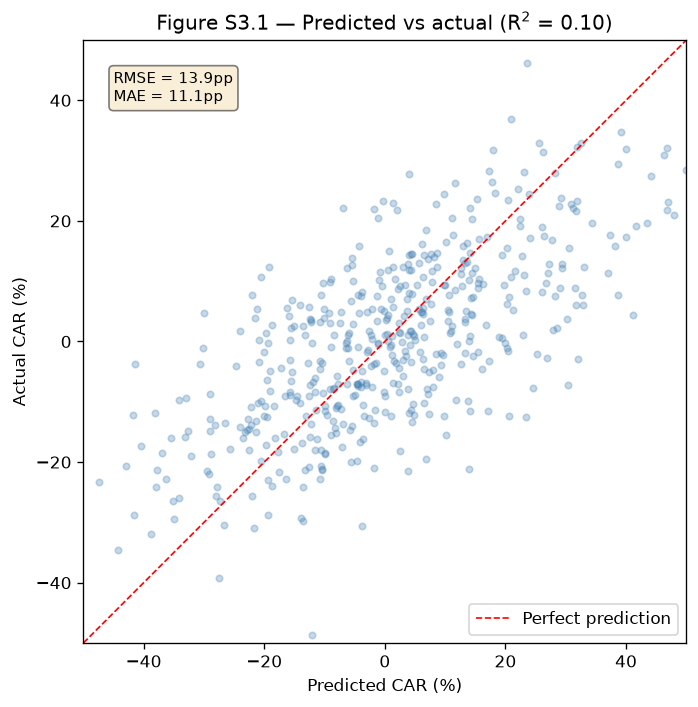

Even with a modest R-squared of 0.10, the scatter shows a clear
positive trend — the model separates the worst outcomes from the best.


In [5]:
# Figure S3.1 — Predicted vs actual scatter plot
from sklearn.metrics import r2_score, mean_squared_error, mean_absolute_error

# Simulate predictions with a known R2 of 0.10 (realistic for financial returns)
rng = np.random.RandomState(42)
n = 500
y_actual = rng.normal(0, 15, n)  # CAR-like distribution, mean 0, std 15%
# Build a predictor with a known R-squared: add noise to the actual values, scaled so the
# residual sum of squares is exactly (1 - R2) of the total. Realised R2 then equals the
# target by construction rather than approximately.
target_r2 = 0.10
resid = rng.normal(0, 1, n)
resid *= np.sqrt((1 - target_r2) * ((y_actual - y_actual.mean()) ** 2).sum() / (resid ** 2).sum())
y_pred_noisy = y_actual + resid
r2 = r2_score(y_actual, y_pred_noisy)

fig, ax = plt.subplots(figsize=(6, 6))
ax.scatter(y_pred_noisy, y_actual, alpha=0.3, s=15, color='steelblue')
lims = [-50, 50]
ax.plot(lims, lims, 'r--', linewidth=1, label='Perfect prediction')
ax.set_xlim(lims); ax.set_ylim(lims)
ax.set_xlabel('Predicted CAR (%)')
ax.set_ylabel('Actual CAR (%)')
ax.set_title(f'Figure S3.1 — Predicted vs actual (R$^2$ = {r2:.2f})')
ax.set_aspect('equal')
ax.legend()
rmse = np.sqrt(mean_squared_error(y_actual, y_pred_noisy))
mae = mean_absolute_error(y_actual, y_pred_noisy)
ax.text(0.05, 0.95, f'RMSE = {rmse:.1f}pp\nMAE = {mae:.1f}pp',
        transform=ax.transAxes, va='top', fontsize=9, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))
plt.tight_layout()
plt.show()
print(f"Even with a modest R-squared of {r2:.2f}, the scatter shows a clear")
print("positive trend — the model separates the worst outcomes from the best.")

### Cross-validated metrics

All of the above metrics should be computed on **out-of-sample** data to assess how well the model will generalise. The cross-validation procedure described in Chapter 5, Section 5.2.5, applies directly:

```python
from sklearn.model_selection import cross_val_score

# Negative MSE (sklearn convention: higher is better)
cv_mse = -cross_val_score(model, X, y, cv=5, scoring='neg_mean_squared_error')
print(f"Mean CV MSE: {cv_mse.mean():.4f}")

cv_r2 = cross_val_score(model, X, y, cv=5, scoring='r2')
print(f"Mean CV R2:  {cv_r2.mean():.4f}")
```

Note that scikit-learn uses the convention that scoring functions should be *maximised*. Because MSE should be minimised, `cross_val_score` returns the negative MSE, which must be negated to obtain the actual MSE.

### $R^2$ does not average across folds

`r2_score` benchmarks the model against the mean of whatever `y_true` it is handed. Under `cross_val_score`, that is the mean of each test fold in turn, so the five numbers returned are measured against five different baselines. They are not five estimates of one quantity, and averaging them does not give the model's out-of-sample $R^2$.

The gap is larger than it sounds. Score the predictions plotted in Figure S3.1 fold by fold — one fixed set of predictions, no refitting, every residual identical to the whole-sample case — and the five values are 0.05, $-0.13$, 0.27, $-0.08$ and 0.25. They average 0.07 against a whole-sample $R^2$ of 0.10, and two of the five report a model worse than predicting that fold's own mean. Nothing about the errors changed — only what each fold was compared against. Re-score the same five folds against one common baseline and they average 0.10 exactly, recovering the whole-sample figure, so the entire averaging gap is a denominator effect. Which particular folds fall below zero is a separate question: one of these two does so because its own variance is low, the other because that is where the largest residuals happened to land.

MSE and MAE do not behave this way. With equal-sized folds their fold values average to the whole-sample value exactly, because what divides the sum is a count rather than a quantity estimated from the fold. RMSE is close but not exact — a square root does not pass through an average.

There are two consequences. First, pool the out-of-fold predictions and score them once instead of averaging fold scores:

```python
from sklearn.model_selection import cross_val_predict

oof = cross_val_predict(model, X, y, cv=5)     # one out-of-sample prediction per row
print(f"Pooled out-of-fold R2: {r2_score(y, oof):.4f}")
```

The pooled figure will not match the average of the fold scores, and that is the point: it is measured against one baseline, the mean of the full sample. These pooled predictions are also what the quintile analysis below requires. Second, `cv=5` on a regression model means `KFold(n_splits=5, shuffle=False)`: rows are split in the order they arrive. If they arrive sorted by anything related to the response — date, sponsor, size — each fold spans less of its range and the fold $R^2$ values fall further. In the limiting case, the same 500 rows sorted by $y$, they run from $-2.0$ to $-37.5$ without a single prediction changing. Pass an explicit `KFold(n_splits=5, shuffle=True, random_state=0)` unless the ordering is deliberate.

> **Exercise S3.1** | A regression model predicting insurance claim amounts produces the following out-of-sample metrics: RMSE = \$12,400, MAE = \$6,200, $R^2$ = 0.35. Interpret each metric in plain language. Explain why the RMSE is approximately double the MAE and what this implies about the distribution of prediction errors.

> **Exercise S3.2** | A colleague reports an in-sample $R^2$ of 0.85 for a model with 200 features and 500 observations. When evaluated using 5-fold cross-validation, the $R^2$ drops to 0.02. Explain what has likely happened and recommend two approaches to address the issue.

### Practical discriminatory power: quintile analysis

Standard regression metrics ($R^2$, RMSE, MAE) summarise average prediction accuracy across the entire dataset. In many business contexts, the question is not 'how accurate is the model on average?' but rather 'can the model reliably distinguish between the best and worst outcomes?' **Quintile analysis** (sometimes called decile analysis or lift analysis) addresses this question directly.

The procedure is:

1. **Generate out-of-sample predictions** using cross-validation. For each observation, record the predicted value $\hat{y}_i$ and the actual value $y_i$.
2. **Sort observations by predicted value** and divide them into five equal-sized groups (quintiles). Quintile 1 contains the observations with the lowest predicted values; Quintile 5 contains the highest.
3. **Compute the mean actual value within each quintile.** If the model has discriminatory power, the mean actual value should increase monotonically from Quintile 1 to Quintile 5.
4. **Report the spread.** The difference in mean actual values between Quintile 5 and Quintile 1 is the **quintile spread**. A large spread indicates that the model can meaningfully distinguish between outcomes.

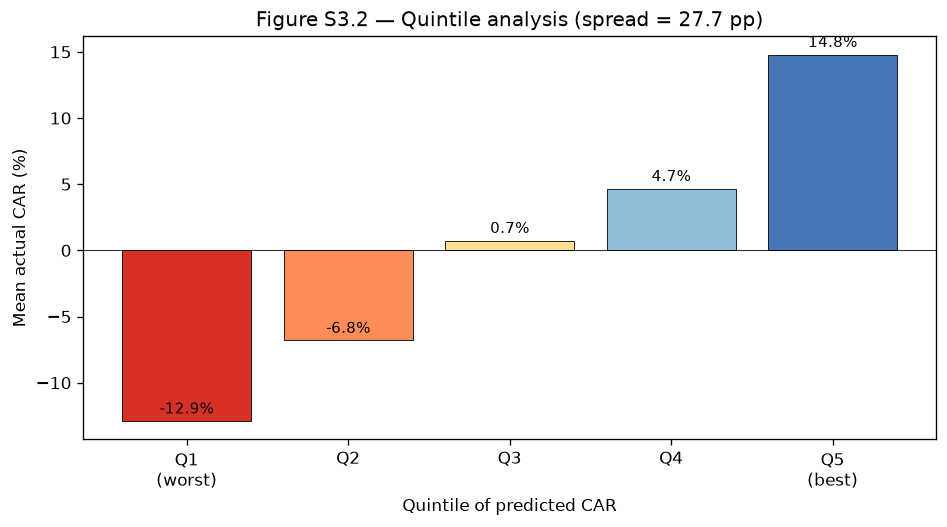

Quintile spread: 27.7 percentage points
The model reliably separates the worst outcomes (Q1) from the best (Q5),
demonstrating practical discriminatory power despite modest R-squared.


In [6]:
# Figure S3.2 — Quintile analysis (illustrative)
df_q = pd.DataFrame({'actual': y_actual, 'predicted': y_pred_noisy})
df_q['quintile'] = pd.qcut(df_q['predicted'], q=5, labels=['Q1\n(worst)', 'Q2', 'Q3', 'Q4', 'Q5\n(best)'])
summary = df_q.groupby('quintile', observed=True)['actual'].agg(['mean', 'median', 'count']).reset_index()

fig, ax = plt.subplots(figsize=(8, 4.5))
colors = ['#d73027', '#fc8d59', '#fee090', '#91bfdb', '#4575b4']
bars = ax.bar(summary['quintile'], summary['mean'], color=colors, edgecolor='black', linewidth=0.5)
ax.axhline(y=0, color='black', linewidth=0.5)
for bar, val in zip(bars, summary['mean']):
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=9)
spread = summary['mean'].iloc[-1] - summary['mean'].iloc[0]
ax.set_ylabel('Mean actual CAR (%)')
ax.set_xlabel('Quintile of predicted CAR')
ax.set_title(f'Figure S3.2 — Quintile analysis (spread = {spread:.1f} pp)')
plt.tight_layout()
plt.show()
print(f"Quintile spread: {spread:.1f} percentage points")
print("The model reliably separates the worst outcomes (Q1) from the best (Q5),")
print("demonstrating practical discriminatory power despite modest R-squared.")

Quintile analysis is particularly informative in the tails: if the bottom quintile reliably identifies the most severe negative reactions, the model has value for risk management even if it cannot precisely predict the magnitude of each individual event.

> **Exercise S3.3** | Using the cross-validated predictions from Exercise S2.2, perform a quintile analysis. Report the mean actual value in each quintile and the quintile spread. Discuss whether the model has practical discriminatory power, even if the overall $R^2$ is low.

---
<a id="S4"></a>
## S4. Ablation analysis

*Extends Chapter 5, Section 5.2.6 (Feature importance)*

**Supports Q3b** — the contribution of each feature group. Also Q4a(iii), which asks what the unavailable features cost.

### Background

Chapter 5 discusses three approaches to understanding which features drive a model's predictions: coefficient-based importance (for linear models), split-based importance (for tree models), and permutation importance (model-agnostic). These methods rank *individual features* by their contribution to model performance. **Ablation analysis** extends this idea to *groups* of features, measuring the contribution of each group to overall model performance.

### Definition

An ablation analysis systematically removes one component at a time from a model and measures the impact on performance. In the context of feature-group evaluation, the procedure is:

1. **Define feature groups.** Partition the full feature set into $G$ non-overlapping groups.
2. **Establish a baseline.** Train the model using all feature groups and evaluate performance using cross-validation.
3. **Remove one group at a time.** For each group $g$, train the model using all feature groups except group $g$ and evaluate performance. The difference between baseline performance and the performance without group $g$ is the **marginal contribution** of group $g$.
4. **Report results.**

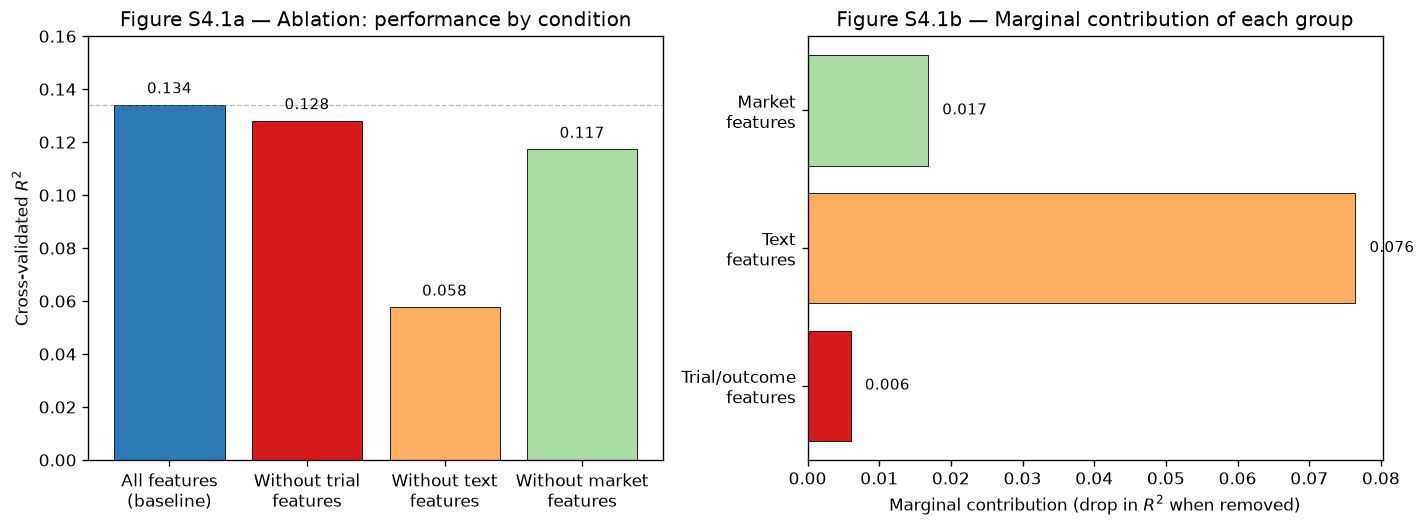

In [7]:
# Figure S4.1 — Ablation analysis (measured on the shipped database, n=2,615, RandomForest, 5-fold CV)
conditions = ['All features\n(baseline)', 'Without trial\nfeatures', 'Without text\nfeatures', 'Without market\nfeatures']
r2_values = [0.1341, 0.1281, 0.0577, 0.1173]
drops = [0, 0.0060, 0.0764, 0.0168]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: absolute R2
bars1 = ax1.bar(conditions, r2_values, color=['#2c7bb6', '#d7191c', '#fdae61', '#abdda4'],
                edgecolor='black', linewidth=0.5)
ax1.axhline(y=0.1341, color='grey', linestyle='--', linewidth=0.8, alpha=0.5)
for bar, val in zip(bars1, r2_values):
    ax1.text(bar.get_x() + bar.get_width()/2, val + 0.003, f'{val:.3f}',
             ha='center', va='bottom', fontsize=9)
ax1.set_ylabel('Cross-validated $R^2$')
ax1.set_title('Figure S4.1a — Ablation: performance by condition')
ax1.set_ylim(0, 0.16)

# Right: marginal contributions
groups = ['Trial/outcome\nfeatures', 'Text\nfeatures', 'Market\nfeatures']
bars2 = ax2.barh(groups, [0.0060, 0.0764, 0.0168], color=['#d7191c', '#fdae61', '#abdda4'],
                 edgecolor='black', linewidth=0.5)
for bar, val in zip(bars2, [0.0060, 0.0764, 0.0168]):
    ax2.text(val + 0.002, bar.get_y() + bar.get_height()/2, f'{val:.3f}',
             ha='left', va='center', fontsize=9)
ax2.set_xlabel('Marginal contribution (drop in $R^2$ when removed)')
ax2.set_title('Figure S4.1b — Marginal contribution of each group')
plt.tight_layout()
plt.show()


### Interpretation

Ablation analysis provides information that individual feature importance measures do not:

- **Group-level contributions.** It answers the question: 'how much value does an entire category of information add to the model?' This is often more actionable for stakeholders than knowing the importance of individual features.
- **Interaction effects.** If two feature groups are redundant (they capture similar information), removing either one alone will have little impact, but the ablation analysis will reveal that neither group adds much *marginal* value over the other.
- **Complementarity.** Conversely, if each group's marginal contribution is large, the groups capture different aspects of the prediction problem and are complementary.

Note that the marginal contributions need not sum to the baseline performance, because of interactions between feature groups.

### Additive variant

An alternative to the 'leave-one-group-out' ablation described above is the 'add-one-group-in' approach:

1. Start with no features (predict the mean).
2. Add one feature group at a time, recording the performance after each addition.

This reveals the *incremental* value of each group when added on top of previous groups. However, the results depend on the order in which groups are added, so it is common to report results for multiple orderings or to report both the 'leave-one-out' and 'add-one-in' variants.

### Feature groups in Figure S4.1

The three feature groups in Figure S4.1 are: **trial/outcome features** (`enrollment`, `n_arm_groups`, `n_interventions`, `n_primary_outcomes`, `n_secondary_outcomes`, `n_locations`, `phase_clean`, `allocation`, `masking`, `intervention_model`, `primary_purpose`); **text features** (`filing_text`, reduced via TF-IDF with a 20,000-term vocabulary, `min_df=3`, followed by `TruncatedSVD` to 50 components); and **market/company features** (`market_cap`, `disclosure_lag_days`, `lead_sponsor_class`, `fda_approved`).

Measured on the shipped database (RandomForest, 5-fold cross-validation, n = 2,615), text features carry the largest marginal contribution and trial features the smallest. That ordering is worth noting because intuition tends to run the other way — trial-design detail looks like it should matter more than boilerplate filing text. Treat the size of the text contribution as an upper bound rather than a settled figure, for the reason given next.

One methodological note applies to the text feature transform specifically: the TF-IDF/SVD pipeline above was fitted on the full dataset before cross-validation, not refit inside each fold. Fitting it inside each fold is the more correct approach, and would be expected to lower the measured text contribution somewhat, since some of what the whole-dataset fit captures is information a fold's training split would not yet have seen. This is precisely the kind of transform-outside-the-CV-loop leakage that Question 3b of the assignment asks you to assess — the same mistake, made here for illustration.

> **Exercise S4.1** | Design an ablation analysis for the customer churn model in Chapter 5, Case Study 1. Define at least three feature groups (e.g. demographic, usage, billing). Explain what each ablation condition would test and how you would interpret the results.

---
<a id="S5"></a>
## S5. Stratified sampling

*Extends Chapter 5, Section 5.2.5 (Validation and generalisation error)*

**Supports Q1a** — the seeded sample of classifications to audit. Also Q2c, for choosing what to inspect.

### Background

Chapter 5 discusses the importance of splitting data into training, validation, and test sets, and introduces cross-validation as a method for estimating generalisation error. An implicit assumption in random splitting is that the resulting subsets are *representative* of the full dataset. When the data contains distinct subgroups of varying sizes, a purely random sample may under-represent rare subgroups. **Stratified sampling** sets the composition of the sample by construction instead: sample within each subgroup separately, and each subgroup's share of the result is fixed rather than drawn. The guarantee is exactly as wide as the variable you stratified on and no wider, which is easy to lose sight of once the folds come back balanced.

### Definition

Stratified sampling is a sampling technique in which the population is divided into non-overlapping subgroups (called **strata**) and samples are drawn independently from each stratum. How many observations to draw from each stratum is a separate choice. *Proportional* allocation, where each stratum contributes in line with its share of the population, is the most common rule and the one assumed below — but it is not the only one. Where a stratum is small and you need to say something about it specifically, deliberately over-sampling it is still stratified sampling (see the answer to Exercise S5.1).

For example, suppose a dataset of 1,000 clinical trial outcomes contains 600 positive outcomes, 300 negative outcomes, and 100 inconclusive outcomes. A stratified sample of 50 observations would draw:

- 30 positive outcomes ($50 \times 600/1000$);
- 15 negative outcomes ($50 \times 300/1000$); and
- 5 inconclusive outcomes ($50 \times 100/1000$).

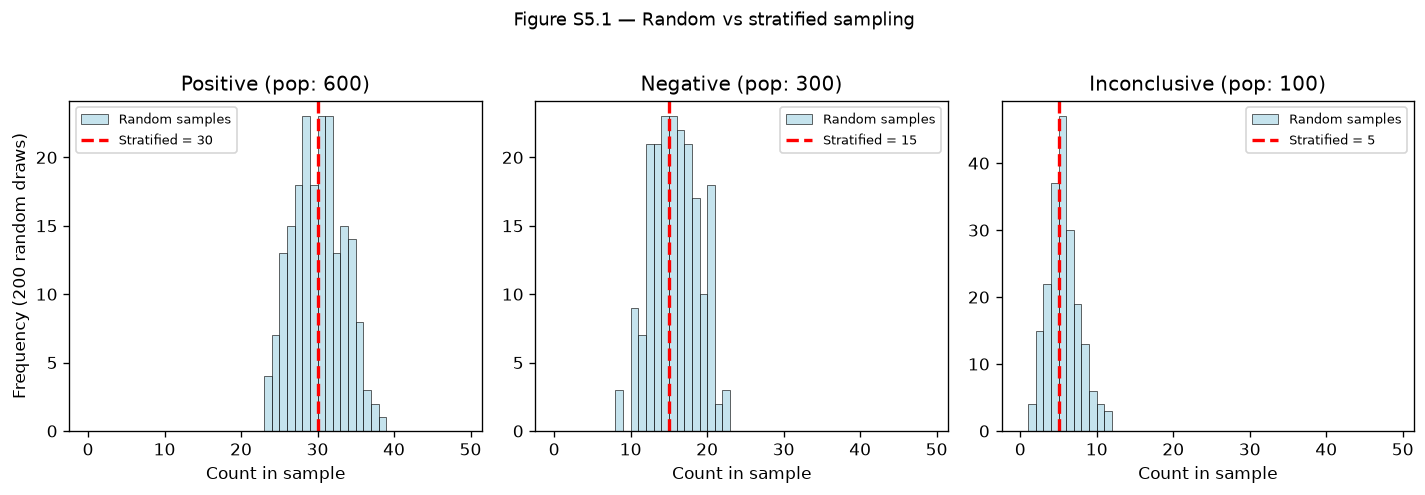

Stratified sampling (red dashed) guarantees proportional representation.
Random sampling (blue histograms) varies — the rarest category lands anywhere from
1 to 11 where 5 was expected, so a small stratum can be badly under-represented.


In [8]:
# Figure S5.1 — Random vs stratified sampling comparison
rng = np.random.RandomState(42)
population = {'Positive': 600, 'Negative': 300, 'Inconclusive': 100}
total = sum(population.values())
sample_size = 50

# Proportional stratified sample
strat_sample = {k: int(round(sample_size * v / total)) for k, v in population.items()}
# Adjust rounding
diff = sample_size - sum(strat_sample.values())
if diff != 0:
    strat_sample['Positive'] += diff

# Simulate 200 random samples and show the distribution
random_draws = []
labels_pop = np.repeat(list(population.keys()), list(population.values()))
for _ in range(200):
    s = rng.choice(labels_pop, size=sample_size, replace=False)
    random_draws.append({k: np.sum(s == k) for k in population})

random_df = pd.DataFrame(random_draws)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
for i, cat in enumerate(population.keys()):
    expected = strat_sample[cat]
    axes[i].hist(random_df[cat], bins=range(0, sample_size), color='lightblue',
                 edgecolor='black', linewidth=0.5, alpha=0.7, label='Random samples')
    axes[i].axvline(x=expected, color='red', linewidth=2, linestyle='--',
                    label=f'Stratified = {expected}')
    axes[i].set_title(f'{cat} (pop: {population[cat]})')
    axes[i].set_xlabel('Count in sample')
    axes[i].legend(fontsize=8)
axes[0].set_ylabel('Frequency (200 random draws)')
fig.suptitle('Figure S5.1 — Random vs stratified sampling', fontsize=11, y=1.02)
plt.tight_layout()
plt.show()
print("Stratified sampling (red dashed) guarantees proportional representation.")
print("Random sampling (blue histograms) varies — the rarest category lands anywhere from")
print("1 to 11 where 5 was expected, so a small stratum can be badly under-represented.")

### Stratified sampling for manual auditing

Stratified sampling is particularly useful when selecting observations for manual review. Consider a task where an analyst must manually check 20 LLM-generated classifications against original source documents. If the classifications span five categories with very different frequencies, a purely random sample of 20 might include no observations from the rarest category, making it impossible to assess accuracy for that category.

### Stratified cross-validation

In **stratified $k$-fold cross-validation**, each fold is constructed to contain approximately the same proportion of each class as the full dataset. This is the default behaviour of `StratifiedKFold` in scikit-learn:

```python
from sklearn.model_selection import StratifiedKFold

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in skf.split(X, y):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
```

**Stratifying a continuous response.** `StratifiedKFold` requires a categorical response. Where the response is continuous — a return, a claim size, a duration — sort observations by the response variable, divide into bins (e.g. deciles), then sample proportionally from each bin for each fold. This ensures that each fold contains the full range of response values, preventing folds that are dominated by low or high values.

### What stratification does not buy you

Stratification is a guarantee about one variable and says nothing about any other. `StratifiedKFold(...).split(X, y)` reads `y` and nothing else, including the columns that decide whether the resulting score means anything.

The event study table shipped with this assignment holds 2,615 rows drawn from 1,905 8-K filings, because a filing reporting on more than one drug or indication contributes more than one row. Work with the 2,573 rows that carry a label and 425 filings still contribute two or more, 1,113 rows between them. Stratify those rows on `outcome_group` using `StratifiedKFold(n_splits=5, shuffle=True, random_state=42)` and 370 of the 425 — seven in eight — end up with rows on both sides of the split in at least one fold. Every fold is balanced on the outcome. Every fold also contains filings the model trained on, so any feature built from the filing text is scored against text it has already read. Nothing objects, because nothing was told that a filing is a unit.

Naming the group as well as the stratum is the fix:

```python
from sklearn.model_selection import StratifiedGroupKFold

sgkf = StratifiedGroupKFold(n_splits=5, shuffle=True, random_state=42)
for train_idx, val_idx in sgkf.split(X, y, groups=df['accession']):
    X_train, X_val = X[train_idx], X[val_idx]
    y_train, y_val = y[train_idx], y[val_idx]
```

The exchange is a looser balance: a filing now has to fall entirely on one side, so the class proportions can only be approximate: on this data the `Inconclusive` share of the validation folds runs from 5.3% to 9.0% against 7.0% overall, where `StratifiedKFold` held every fold between 7.0% and 7.2%. And `accession` is only one candidate group. The same rows come from 317 tickers, of which PFE alone supplies 94, so a model with company-level features can learn the registrant rather than the result. Whether that is leakage or a legitimate predictor depends on the question being asked, and stratification will not answer it for you. It balances the column you hand it and leaves every other column to chance.

### Reproducibility

When drawing stratified samples, set a **random seed** so that the sample is reproducible:

```python
# n= per stratum rather than frac=, so the total is exactly 20 rather than
# approximately 20; include_groups=False silences a pandas deprecation.
shares = (df['outcome_group'].value_counts(normalize=True) * 20).round().astype(int)
sample = df.groupby('outcome_group', group_keys=False).apply(
    lambda x: x.sample(n=shares[x.name], random_state=42), include_groups=False
)
```

In an assessment context, using a candidate-specific seed (e.g. candidate number) ensures that each candidate reviews a different sample, reducing the risk of shared answers while maintaining reproducibility for marking purposes.

> **Exercise S5.1** | A dataset contains 2,000 insurance claims classified into four categories: property (1,200), motor (500), liability (200), and professional indemnity (100). An auditor needs to manually review 40 claims. Calculate the number of claims to draw from each category using proportional stratified sampling. Discuss whether proportional allocation is appropriate here or whether *disproportional* allocation (e.g. equal numbers per category) might be preferable for the auditing purpose.

---
<a id="S6"></a>
## S6. Sentence embeddings

*Extends Chapter 7, Section 7.2.4 (Vectorisation), in particular its Word embeddings subsection*

**Supports Q1c** — embeddings with dimensionality reduction, and what truncation does to a long 8-K filing. The features built here are used again in Q2a and Q3a.

### Background

Chapter 7 introduces word embeddings (Word2Vec, GloVe, fastText) as a method for representing individual words as dense vectors that capture semantic meaning. A limitation of word embeddings is that they operate at the *word* level: each word receives a single vector regardless of context, and there is no direct mechanism for producing a fixed-length vector representation of a *sentence*, *paragraph*, or *document*.

In many practical tasks — such as clustering documents, computing document similarity, or using text as features in a regression model — a single fixed-length vector per document is needed. Producing one that genuinely reflects the whole document takes more care than it appears; see "Documents longer than the model's input window" below. **Sentence embeddings** address this need.

### From words to sentences

There are several approaches to deriving sentence-level representations:

1. **Averaging.** Compute the mean of all word embedding vectors in a sentence. Simple but discards word order.
2. **Weighted averaging.** Weight words by their TF-IDF scores before averaging, so that rare, informative words contribute more.
3. **Dedicated sentence embedding models.** Purpose-built models learn to produce sentence-level representations directly.

### Sentence transformers

The most widely used approach is based on **sentence transformers**, which are transformer models (Chapter 7, Section 7.3.3) fine-tuned specifically for producing semantically meaningful sentence representations.

The key model family is **Sentence-BERT** (SBERT). A commonly used model is `all-MiniLM-L6-v2`, which produces 384-dimensional sentence embeddings (22 million parameters vs. BERT's 110 million).

```python
from sentence_transformers import SentenceTransformer

model = SentenceTransformer('all-MiniLM-L6-v2')
sentences = [
    "The Phase 3 trial met its primary endpoint.",
    "The drug failed to demonstrate efficacy in the pivotal study.",
    "Weather conditions were mild across the eastern seaboard."
]
embeddings = model.encode(sentences)
print(embeddings.shape)  # (3, 384)
```

### Documents longer than the model's input window

Every transformer model has a maximum input length, measured in tokens, fixed when the model was trained. A token is roughly three to four characters of English, so a few hundred tokens is of the order of a couple of thousand characters — far shorter than many real business documents.

Text beyond the limit is discarded silently. `model.encode()` does not raise an error and does not warn: it truncates the input, embeds what is left, and returns a vector of the usual shape. An embedding built from the first paragraph of a long document is indistinguishable, by inspection, from one built from the whole document.

This is not a hypothetical margin. `all-MiniLM-L6-v2`, the model used above, reads **256 tokens**. The 8-K filings in this assignment's dataset have a median length of roughly 19,000 characters — on the order of 4,800 tokens — so passing one to `encode()` unmodified embeds about the first 6% of it. For an 8-K that opening 6% is the cover page: the form type, the registrant's name and address, and the item number. Two filings reporting opposite trial outcomes can produce near-identical vectors on that basis.

Check the limit, and check your documents against it, before you encode:

```python
model = SentenceTransformer('all-MiniLM-L6-v2')
print(model.max_seq_length)                                  # tokens the model will read
lengths = [len(model.tokenizer.tokenize(t)) for t in texts[:200]]
print(pd.Series(lengths).describe())                         # how far over the limit are you?
```

Where documents exceed the limit, three strategies are common. Each discards or dilutes information, and the choice should be stated and justified:

| Strategy | What it does | What it costs |
|----------|--------------|---------------|
| Truncate | Embed the first *N* tokens only | Loses everything after the cut; safe only where the informative material is reliably at the front |
| Head + tail | Embed the opening and closing portions and concatenate or average them | Loses the middle |
| Chunk and pool | Split into overlapping windows, embed each, then average or max-pool the vectors | Retains coverage but dilutes a short decisive passage into a document-length average, and costs *k* times the compute |

Where the documents have a predictable structure there is a fourth option: extract the section that carries the information you need and embed only that. It is usually the strongest choice, because it makes the discarded material an explicit decision rather than an artefact of where the cut happened to fall.

Chunk-and-pool, written out, is short:

```python
import numpy as np

def chunk_tokens(text, tokenizer, max_tokens, overlap=50):
    """Overlapping token windows. A passage shorter than the overlap is
    guaranteed to appear intact in at least one window."""
    ids = tokenizer.encode(text, add_special_tokens=False)
    if len(ids) <= max_tokens:
        return [text]
    step = max(1, max_tokens - overlap)
    return [tokenizer.decode(ids[i:i + max_tokens])
            for i in range(0, len(ids), step)]

def embed_document(text, model):
    """One vector per document: embed every chunk, then mean-pool."""
    # -2 leaves room for [CLS] and [SEP], which count towards max_seq_length.
    chunks = chunk_tokens(text, model.tokenizer, model.max_seq_length - 2)
    vectors = model.encode(chunks, normalize_embeddings=True)
    pooled = vectors.mean(axis=0)
    return pooled / np.linalg.norm(pooled)   # re-normalise: the mean of unit
                                             # vectors is not a unit vector

doc_vectors = np.vstack([embed_document(t, model) for t in texts])
```

Two things to note. The cost is roughly *k* times a single `encode()` call, where *k* is the number of chunks, so check the document-length distribution before running this over a large corpus. And pooling averages a decisive sentence into a document-length mean — if one paragraph carries the signal, extracting that section will beat pooling the whole document.

Whichever you choose, record what you did and what it cost. A model whose write-up does not say which part of the document was read cannot be reproduced.


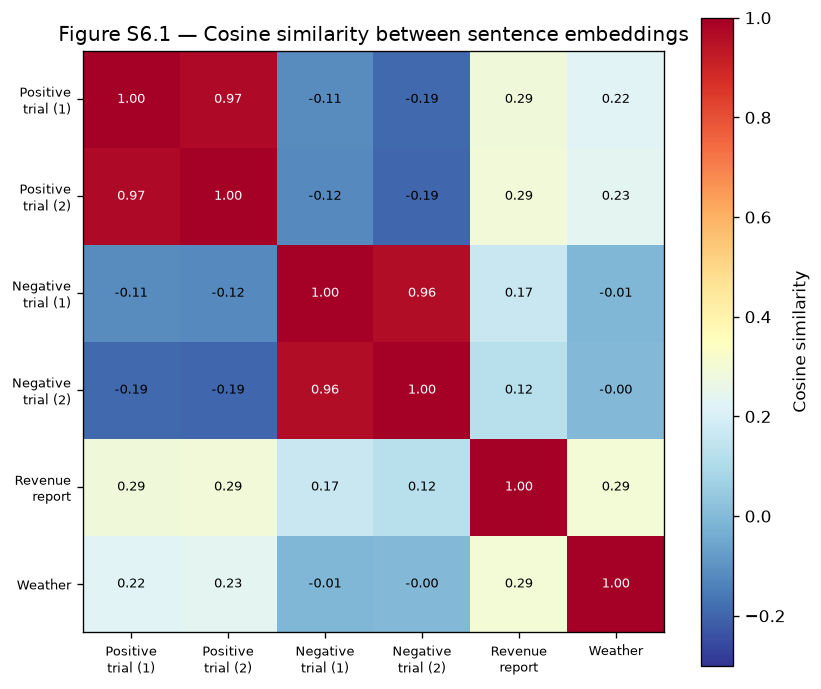

Semantically similar sentences (e.g. both 'positive trial' descriptions)
have high cosine similarity. Unrelated sentences (weather) are dissimilar.


In [9]:
# Figure S6.1 — Cosine similarity between sentence embeddings (illustrative)
# The embeddings here are simulated, so this section runs anywhere without waiting
# on a large download. Real sentence-transformer embeddings need `sentence-transformers`
# and `torch`, roughly 2GB — install those when you come to vectorise the filings
# yourself in Question 1c. The point being made is about the similarities, not the model.
from sklearn.metrics.pairwise import cosine_similarity

sentences = [
    "Phase 3 trial met its primary endpoint",
    "Pivotal study showed statistically significant efficacy",
    "Drug failed to demonstrate clinical benefit",
    "Trial stopped for futility after interim analysis",
    "Revenue increased 15% year over year",
    "Weather conditions were mild"
]

# Simulated embeddings that capture semantic similarity
rng = np.random.RandomState(42)
base = rng.randn(6, 50)
# Make sentences 0,1 similar (positive trial); 2,3 similar (negative trial)
base[1] = base[0] + rng.randn(50) * 0.3
base[3] = base[2] + rng.randn(50) * 0.3

sim_matrix = cosine_similarity(base)

fig, ax = plt.subplots(figsize=(7, 6))
im = ax.imshow(sim_matrix, cmap='RdYlBu_r', vmin=-0.3, vmax=1.0)
ax.set_xticks(range(6))
ax.set_yticks(range(6))
short_labels = ['Positive\ntrial (1)', 'Positive\ntrial (2)', 'Negative\ntrial (1)',
                'Negative\ntrial (2)', 'Revenue\nreport', 'Weather']
ax.set_xticklabels(short_labels, fontsize=8)
ax.set_yticklabels(short_labels, fontsize=8)
for i in range(6):
    for j in range(6):
        ax.text(j, i, f'{sim_matrix[i,j]:.2f}', ha='center', va='center', fontsize=8,
                color='white' if sim_matrix[i,j] > 0.6 else 'black')
plt.colorbar(im, ax=ax, label='Cosine similarity')
ax.set_title('Figure S6.1 — Cosine similarity between sentence embeddings')
plt.tight_layout()
plt.show()
print("Semantically similar sentences (e.g. both 'positive trial' descriptions)")
print("have high cosine similarity. Unrelated sentences (weather) are dissimilar.")

### Dimensionality reduction of embeddings

Sentence embeddings are typically high-dimensional (e.g. 384 or 768 dimensions). When used as features alongside other variables, it is often beneficial to reduce the dimensionality using PCA (Chapter 6, Section 6.2.1):

```python
from sklearn.decomposition import PCA

pca = PCA(n_components=50)
embeddings_reduced = pca.fit_transform(embeddings)
print(f"Variance retained: {pca.explained_variance_ratio_.sum():.1%}")
```

### Comparison with TF-IDF

| Property | TF-IDF | Sentence embeddings |
|----------|--------|-------------------|
| Representation | Sparse, high-dimensional | Dense, fixed-dimensional |
| Semantic understanding | None (bag of words) | Yes (contextual meaning) |
| Interpretability | High (each dimension = a word) | Low (dimensions are latent) |
| Vocabulary dependence | Yes (unseen words are ignored) | Partial (fixed subword vocabulary; unseen words are split into known pieces) |

In practice, using both TF-IDF and sentence embeddings as features can be beneficial, as they provide complementary information.

> **Exercise S6.1** | Using the travel insurance complaints from Case Study 2 in Chapter 7, compute sentence embeddings using `all-MiniLM-L6-v2` and TF-IDF vectors for the same documents. Compute the cosine similarity between two complaints about the same topic and two about different topics, using both representations. Discuss which representation better captures semantic similarity.

---
<a id="S7"></a>
## S7. Domain-specific transformer models

*Extends Chapter 7, Section 7.3.3 (BERT)*

**Supports Q3a** — one of the two required text representations. Also Q1c.

### Background

Chapter 7 introduces BERT as a pre-trained transformer model that can be fine-tuned for downstream NLP tasks. BERT was trained on general-purpose text (Wikipedia and BookCorpus), and its WordPiece vocabulary was learned from that same text. A term that is rare there is not held as a word at all: BERT splits 'haemophilia' into `ha ##em ##op ##hil ##ia`, five fragments to be reassembled on every reading.

A **domain-specific transformer model** is the same architecture with further pre-training on a domain corpus and, where the model was built from scratch rather than continued from BERT, a vocabulary rebuilt from it — BioBERT inherited BERT's vocabulary and splits 'haemophilia' the same five ways, while PubMedBERT holds it as a single token. The architecture is untouched. FinBERT is BERT-base: 12 layers, 768 dimensions, a 512-token input window. Section S6's truncation problem therefore arrives here with the window merely twice as wide. Three of the 3,794 filings in `filing_text` fit inside 512 tokens; for the median filing you read about the first 12%, against S6's 6%. A domain model knows more about the words it reads; it does not read more of the document.

### Why domain-specific models matter

Consider the word 'positive' in three contexts:

- *General English:* 'She had a positive attitude.' (Sentiment: good)
- *Medicine:* 'The patient tested positive for the virus.' (Sentiment: bad)
- *Finance:* 'The company reported positive earnings.' (Sentiment: good)

A general-purpose model may not reliably distinguish between these contexts.

### Key domain-specific models

**FinBERT** is the name of two different models, and which one you load matters. The one published as `ProsusAI/finbert` is pre-trained on Reuters financial news and fine-tuned on the Financial PhraseBank. The other is pre-trained on 10-K and 10-Q filings, earnings call transcripts and analyst reports — the closer match if your text is SEC filings, as it is in this assignment. Both outperform general-purpose sentiment tools on financial text.

**DistilBERT** is a distilled version of BERT that retains ~97% of BERT's performance on the GLUE benchmark while being 40% smaller and 60% faster (66M vs 110M parameters).

| Model | Domain | Pre-training corpus |
|-------|--------|-------------------|
| FinBERT | Financial | Financial news, earnings calls, SEC filings |
| BioBERT | Biomedical | PubMed abstracts, PMC full-text |
| SciBERT | Scientific | Semantic Scholar papers |
| ClinicalBERT | Clinical | MIMIC-III clinical notes |
| LegalBERT | Legal | Legal opinions, contracts, legislation |
| PubMedBERT | Biomedical | PubMed abstracts (from scratch) |

### What the sentiment output is

FinBERT's classification head returns one of three labels — positive, negative, neutral — with a probability attached. The Financial PhraseBank it was fine-tuned on is single sentences from financial news, annotated for the direction in which a reader would expect them to move a price. An 8-K item is neither single-sentence nor news, and the label describes only the 512 tokens the model saw.

That label is also the wrong quantity for Question 3. Direction is already in the dataset, in the outcome classification you assessed in Question 1a; Question 3 asks how far the price moved, not which way, and a three-way label carries no magnitude. A sentiment feature that agrees with the outcome will still appear to contribute, because it is close to a copy of a column the dataset already holds. And direction is a weaker guide to magnitude here than it looks: of the 1,944 events labelled `Positive` in `event_study_enriched`, 1,014 — 52.2% — were followed by a *negative* three-day abnormal return. Knowing which way the filing reads does not tell you which way the price moved, let alone how far. The filings worth isolating are the ones where sentiment and outcome disagree: a failure disclosed in confident language, a success heavily hedged.

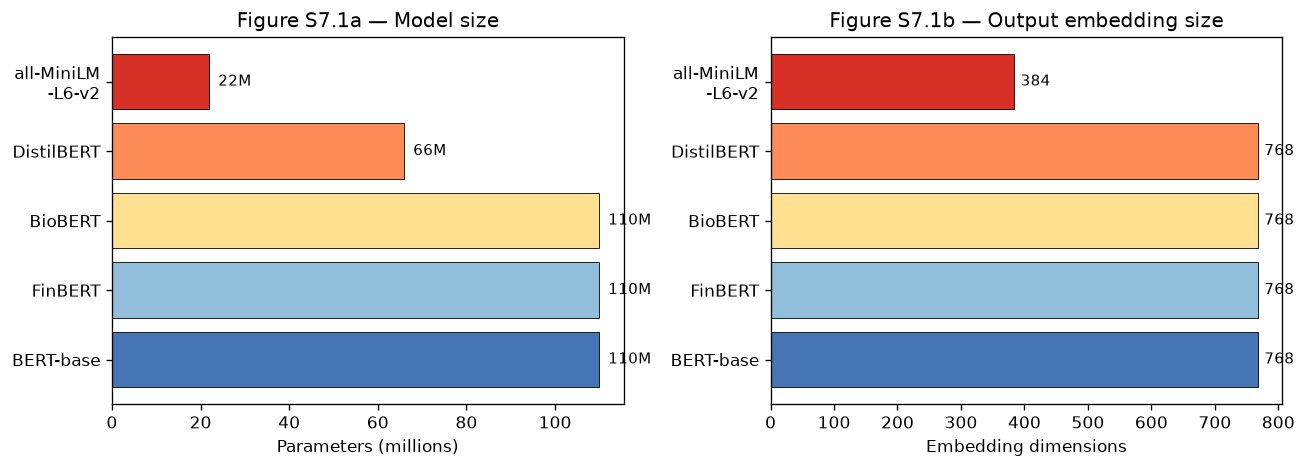

In [10]:
# Figure S7.1 — Transformer model size comparison
models = ['BERT-base', 'FinBERT', 'BioBERT', 'DistilBERT', 'all-MiniLM\n-L6-v2']
params = [110, 110, 110, 66, 22]
layers = [12, 12, 12, 6, 6]
dims = [768, 768, 768, 768, 384]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(11, 4))

colors = ['#4575b4', '#91bfdb', '#fee090', '#fc8d59', '#d73027']
ax1.barh(models, params, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(params):
    ax1.text(v + 2, i, f'{v}M', va='center', fontsize=9)
ax1.set_xlabel('Parameters (millions)')
ax1.set_title('Figure S7.1a — Model size')

ax2.barh(models, dims, color=colors, edgecolor='black', linewidth=0.5)
for i, v in enumerate(dims):
    ax2.text(v + 10, i, str(v), va='center', fontsize=9)
ax2.set_xlabel('Embedding dimensions')
ax2.set_title('Figure S7.1b — Output embedding size')
plt.tight_layout()
plt.show()

### Using domain-specific models for feature extraction

Domain-specific transformer models can be used in two ways:

1. **Classification.** Fine-tune the model on a labelled dataset to classify text (e.g. sentiment classification).
2. **Feature extraction.** Use the model to generate dense vector representations (embeddings) of text, then use these embeddings as features in a downstream model such as ridge regression or gradient boosting.

When using transformer models for feature extraction, a common approach is to:

1. Check the document length against the model's maximum input length, and apply an explicit strategy where it is exceeded (see Section S6).
2. Pass the text through the model.
3. Extract the hidden state vectors from the final layer.
4. Apply mean pooling over token positions to produce a single fixed-length vector.
5. Optionally reduce dimensionality using PCA (see Section S6).

> **Exercise S7.1** | Explain why a model pre-trained on general English text might misinterpret the phrase 'the trial was terminated early' in a clinical trial context. How might a domain-specific model such as BioBERT or ClinicalBERT handle this differently?

---
<a id="S8"></a>
## S8. Domain-specific sentiment lexicons

*Extends Chapter 7, Section 7.4.3 (Sentiment analysis)*

**Supports Q3a** — a second, contrasting text representation.

### Background

Chapter 7 introduces sentiment analysis as the task of determining the emotional tone of text. **Sentiment lexicons** are the cheapest implementation of it: a pre-built dictionary assigns a score or a category to individual words, and a document's sentiment is a count of the words it contains. That is the entire mechanism. It is why the method scales to a whole corpus on a laptop, and it is why the method has no representation for the word 'not' — scored on the Loughran-McDonald dictionary introduced below, *did not achieve the primary endpoint* returns one positive word and no negative ones, the same tally as *achieved the primary endpoint*. Swapping in a domain-specific lexicon changes which words are in which list, and leaves that counting rule exactly as it is.

### The Loughran-McDonald financial sentiment dictionary

The **Loughran-McDonald** dictionary was developed specifically for financial text, based on their analysis of over 50,000 annual reports (10-K filings). Their key finding was that general-purpose sentiment dictionaries misclassify a large proportion of words in financial text. For example, 'liability' is classified as negative in general-purpose dictionaries, but in financial text it is a neutral accounting term. Nearly three-quarters of the words classified as negative by the Harvard General Inquirer dictionary are not negative in a financial context.

The Loughran-McDonald dictionary classifies words into six categories:

| Category | Description | Example words |
|----------|-------------|---------------|
| Negative | Adverse outcomes | 'loss', 'decline', 'impairment', 'default', 'breach' |
| Positive | Favourable outcomes | 'achieve', 'benefit', 'gain', 'improve', 'surpass' |
| Uncertainty | Doubt or ambiguity | 'approximate', 'contingent', 'depend', 'fluctuate', 'risk' |
| Litigious | Legal proceedings | 'claimant', 'defendant', 'lawsuit', 'tribunal', 'verdict' |
| Strong modal | Strong obligation | 'shall', 'must', 'will', 'always', 'highest' |
| Weak modal | Weak obligation | 'could', 'may', 'might', 'possibly', 'suggest' |

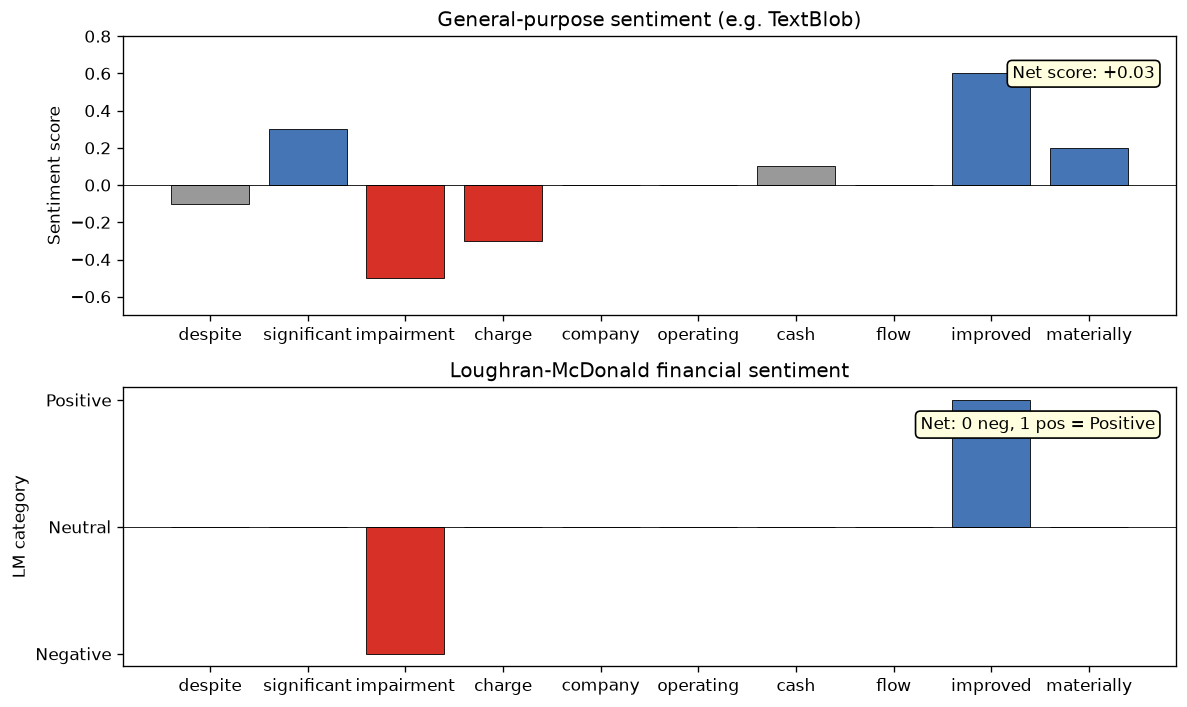

General-purpose: scores 'significant' (+0.3) and 'charge' (-0.3) as sentiment-bearing.
Neither carries sentiment in a financial register. The misreadings partly cancel, so the
net score (+0.03) looks unremarkable while the word-level attribution is wrong.
Loughran-McDonald: correctly treats "significant", "charge" as neutral financial terms.
Only "impairment" (negative) and "improved" (positive) carry sentiment.


In [11]:
# Figure S8.1 — General-purpose vs financial sentiment scoring
# Example sentence from financial reporting
sentence = "Despite the significant impairment charge, the company's operating cash flow improved materially."

# Simulated general-purpose scores (word-level)
words_gen = {
    'despite': -0.1, 'significant': 0.3, 'impairment': -0.5, 'charge': -0.3,
    'company': 0.0, 'operating': 0.0, 'cash': 0.1, 'flow': 0.0,
    'improved': 0.6, 'materially': 0.2
}

# Loughran-McDonald classification
words_lm = {
    'despite': 'Neutral', 'significant': 'Neutral', 'impairment': 'Negative', 'charge': 'Neutral',
    'company': 'Neutral', 'operating': 'Neutral', 'cash': 'Neutral', 'flow': 'Neutral',
    'improved': 'Positive', 'materially': 'Neutral'
}

fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(10, 6), gridspec_kw={'height_ratios': [1, 1]})

# General purpose
words = list(words_gen.keys())
scores = list(words_gen.values())
colors_gen = ['#d73027' if s < -0.1 else '#4575b4' if s > 0.1 else '#999999' for s in scores]
ax1.bar(words, scores, color=colors_gen, edgecolor='black', linewidth=0.5)
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_ylabel('Sentiment score')
ax1.set_title('General-purpose sentiment (e.g. TextBlob)')
ax1.set_ylim(-0.7, 0.8)
net_gen = sum(scores) / len(scores)
ax1.text(0.98, 0.85, f'Net score: {net_gen:+.2f}', transform=ax1.transAxes,
         ha='right', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))

# Loughran-McDonald
lm_colors = {'Negative': '#d73027', 'Positive': '#4575b4', 'Neutral': '#999999'}
bar_colors = [lm_colors[words_lm[w]] for w in words]
bar_heights = [{'Negative': -1, 'Positive': 1, 'Neutral': 0}[words_lm[w]] for w in words]
ax2.bar(words, bar_heights, color=bar_colors, edgecolor='black', linewidth=0.5)
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('LM category')
ax2.set_yticks([-1, 0, 1])
ax2.set_yticklabels(['Negative', 'Neutral', 'Positive'])
ax2.set_title('Loughran-McDonald financial sentiment')
ax2.text(0.98, 0.85, 'Net: 0 neg, 1 pos = Positive', transform=ax2.transAxes,
         ha='right', fontsize=10, bbox=dict(boxstyle='round', facecolor='lightyellow'))
plt.tight_layout()
plt.show()
print("General-purpose: scores 'significant' (+0.3) and 'charge' (-0.3) as sentiment-bearing.")
print(f"Neither carries sentiment in a financial register. The misreadings partly cancel, so the")
print(f"net score ({net_gen:+.2f}) looks unremarkable while the word-level attribution is wrong.")
print('Loughran-McDonald: correctly treats "significant", "charge" as neutral financial terms.')
print('Only "impairment" (negative) and "improved" (positive) carry sentiment.')

### Comparison with model-based sentiment

| Property | Lexicon-based | Model-based (FinBERT) |
|----------|--------------|----------------------|
| Interpretability | High — can inspect which words contributed | Low — outputs a score without explanation |
| Context sensitivity | None — each word scored independently | High — considers surrounding words |
| Domain specificity | High (if using domain lexicon) | Depends on pre-training corpus |
| Computation | Very fast (dictionary lookup) | Slower (neural network inference) |
| Negation handling | Limited (unless rules added) | Generally handled well |

The negation row is the one that bites. *The trial failed to achieve the primary endpoint* — a routine phrasing in trial announcements — contains one Loughran-McDonald negative word ('failed') and one positive ('achieve'). They cancel, and the filing scores neutral: indistinguishable from one that says nothing either way. A negation rule can be bolted on, but it is a fixed lookback window over a language that does not respect one, and it is yours to write and to defend. The argument for carrying both a lexicon and a model feature rests on this one case: the model reads word order and so can separate the filings the lexicon nets to zero. Whether it does so on these filings is measurable — score both, and look only at the rows where the lexicon returns neutral.

> **Exercise S8.1** | Consider the sentence: 'Despite the significant impairment charge, the company's operating cash flow improved materially.' Score this sentence using (a) a general-purpose sentiment tool (e.g. TextBlob) and (b) the Loughran-McDonald dictionary categories. Discuss how the two approaches differ and which better captures the financial sentiment of the sentence.

---
<a id="S9"></a>
## S9. Scenario analysis

*Extends Chapter 8, Section 8.2.3 (Design solution)*

**Supports Q4a** — constructing the positive, negative and mixed scenarios and stating a range for each. Also Q3c, through the within-subgroup evaluation below.

### Background

Chapter 8 introduces frameworks for structuring business decisions under uncertainty. This section provides a more structured treatment of **scenario analysis** as a technique for decision-making under uncertainty.

### Definition

Scenario analysis is a structured process for evaluating potential outcomes by constructing and analysing a set of plausible future states. Unlike point forecasting, it explicitly acknowledges uncertainty by considering multiple outcomes and their implications.

### Framework

A well-constructed scenario analysis includes:

1. **Scenario definition.** Identify distinct, plausible future states. For clinical trial outcomes, these naturally correspond to outcome categories (positive, negative, mixed/inconclusive).

2. **Probability assignment.** Estimate the probability of each scenario. Base rates from historical data (e.g. the proportion of trials in each outcome category) provide a starting point, but should be adjusted for the specific context (drug mechanism, phase, sponsor track record).

3. **Impact quantification.** For each scenario, estimate the financial impact. In an event study context, this means estimating the likely abnormal return range — not just the average, but the spread (e.g. interquartile range, 5th–95th percentile).

4. **Expected value and risk metrics.** Calculate the probability-weighted expected outcome, but also consider downside risk (worst-case scenario magnitude, value at risk) and the full distribution of outcomes.

### Asymmetric predictability

An important finding in event study analysis is that negative outcomes tend to be more predictable in magnitude than positive outcomes. This has implications for scenario construction:

- **Negative scenarios** may warrant narrower ranges, because historical data provides stronger signal about crash severity.
- **Positive scenarios** may warrant wider ranges, because the magnitude of positive reactions is harder to predict.

This asymmetry can be evaluated by computing **within-subgroup metrics** — fitting or evaluating a model separately within positive and negative outcome groups:

$$R^2_{\text{negative}} = 1 - \frac{\sum_{i \in \text{neg}} (y_i - \hat{y}_i)^2}{\sum_{i \in \text{neg}} (y_i - \bar{y}_{\text{neg}})^2}$$

If $R^2_{\text{negative}} \gg R^2_{\text{positive}}$, this indicates that the model has more discriminatory power for downside scenarios.

### Why might negative reactions be more predictable?

Several factors from the finance and behavioural economics literature suggest why:

1. **Heterogeneity of failure modes.** Negative trial outcomes vary widely — safety failures, efficacy misses, futility analyses, regulatory holds — and each type carries different market severity. This variation gives the model more signal. Positive outcomes are more homogeneous ("met primary endpoint").

2. **Information content.** Bad-news disclosures in 8-K filings tend to be more detailed about what went wrong, providing richer text features for prediction.

3. **Loss aversion.** Prospect theory suggests that investors weight losses more heavily than equivalent gains. This asymmetric psychological response may produce more consistent (and therefore more predictable) negative reactions.

4. **Prior expectations.** Positive outcomes for late-phase trials may already be partially priced in (the market expects success), while negative outcomes are more often genuine surprises, producing larger and more predictable crashes.

5. **Information asymmetry in bad-news disclosures.** Managers control the timing and framing of a disclosure, and have an incentive to delay, soften, or bury genuinely bad news within a filing. Good news carries no equivalent incentive to obscure it. This asymmetry between what the filer knows and what the market can extract from the text is a further reason negative announcements may carry a more distinctive, learnable signal than positive ones.

- This asymmetry is itself a useful finding to communicate: it tells the decision-maker that the analysis provides more reliable guidance for managing downside risk than for forecasting upside potential.

> **Exercise S9.1** | A general insurance company is considering entering a new market (cyber insurance). Construct a scenario analysis with three scenarios (optimistic, base, pessimistic) covering: (a) market growth, (b) loss experience, and (c) competitive dynamics. Assign probabilities. Discuss how this would feed into a decision about initial capital allocation.

> **Exercise S9.2** | A colleague presents a scenario analysis: Scenario A (50% probability, +\$10M NPV), Scenario B (30% probability, +\$2M NPV), Scenario C (20% probability, -\$15M NPV). Calculate the expected NPV. Explain why the expected NPV alone is insufficient for making a decision.

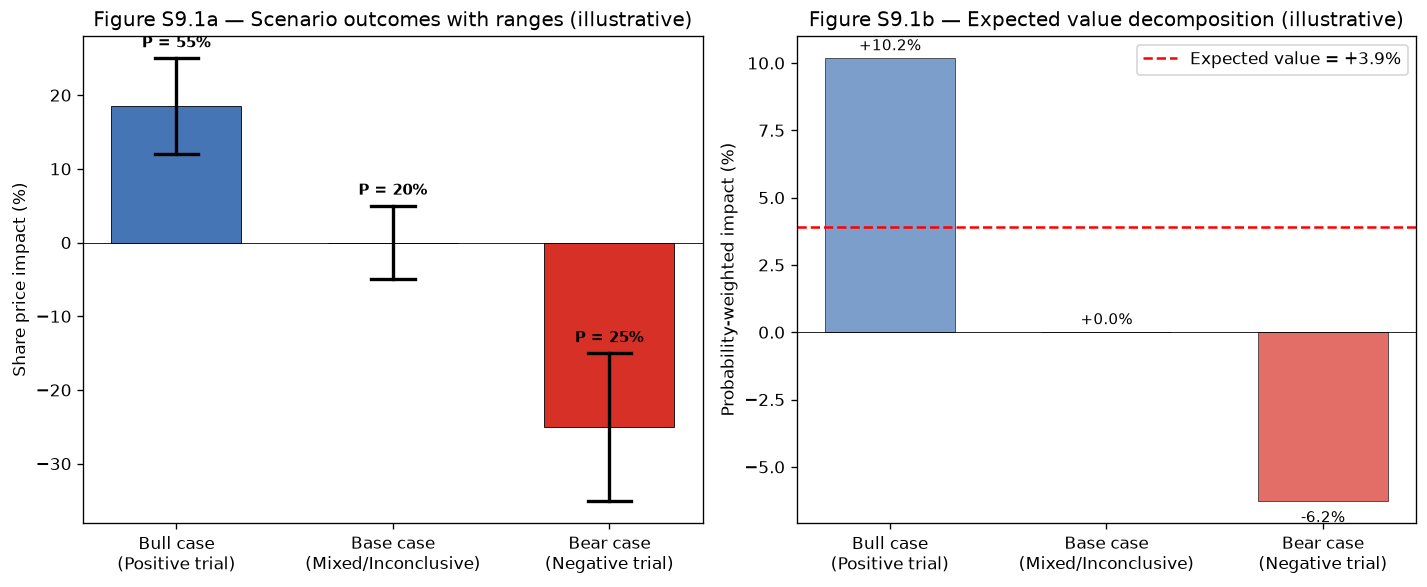

Illustrative figures — invented to show the method, not estimated from this dataset.
Expected share price impact: +3.9%
But the expected value masks the asymmetry: the downside (-25%) is larger than the upside (+18.5%).


In [12]:
# Figure S9.1 — Scenario analysis: expected payoffs under uncertainty
# ILLUSTRATIVE. The probabilities and price impacts below are invented to show the
# shape of a scenario analysis. They are not estimates for this dataset.
scenarios = ['Bull case\n(Positive trial)', 'Base case\n(Mixed/Inconclusive)', 'Bear case\n(Negative trial)']
probabilities = [0.55, 0.20, 0.25]
price_impacts = [18.5, 0, -25]  # midpoint of ranges
price_ranges = [(12, 25), (-5, 5), (-35, -15)]

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: probability-weighted outcomes
colors = ['#4575b4', '#fee090', '#d73027']
bars = ax1.bar(scenarios, price_impacts, color=colors, edgecolor='black', linewidth=0.5, width=0.6)
for i, (bar, bounds, prob) in enumerate(zip(bars, price_ranges, probabilities)):
    mid = price_impacts[i]
    ax1.plot([i, i], [bounds[0], bounds[1]], color='black', linewidth=2, zorder=5)
    ax1.plot([i-0.1, i+0.1], [bounds[0], bounds[0]], color='black', linewidth=2)
    ax1.plot([i-0.1, i+0.1], [bounds[1], bounds[1]], color='black', linewidth=2)
    ax1.text(i, bounds[1] + 1.5, f'P = {prob:.0%}', ha='center', fontsize=9, fontweight='bold')
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_ylabel('Share price impact (%)')
ax1.set_title('Figure S9.1a — Scenario outcomes with ranges (illustrative)')

# Right: expected value calculation
ev = sum(p * i for p, i in zip(probabilities, price_impacts))
contrib = [p * i for p, i in zip(probabilities, price_impacts)]
bars2 = ax2.bar(scenarios, contrib, color=colors, edgecolor='black', linewidth=0.5, width=0.6, alpha=0.7)
for bar, val in zip(bars2, contrib):
    ax2.text(bar.get_x() + bar.get_width()/2, val + (0.3 if val >= 0 else -0.8),
             f'{val:+.1f}%', ha='center', fontsize=9)
ax2.axhline(y=ev, color='red', linestyle='--', linewidth=1.5, label=f'Expected value = {ev:+.1f}%')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('Probability-weighted impact (%)')
ax2.set_title('Figure S9.1b — Expected value decomposition (illustrative)')
ax2.legend()
plt.tight_layout()
plt.show()
print("Illustrative figures — invented to show the method, not estimated from this dataset.")
print(f"Expected share price impact: {ev:+.1f}%")
print("But the expected value masks the asymmetry: the downside (-25%) is larger than the upside (+18.5%).")

### Practical considerations

**Sample size.** When scenario probabilities are estimated from historical data, reliability depends on sample size. A scenario based on 200 comparable cases provides more reliable estimates than one based on 8 cases.

**False precision.** Reporting 'the probability of a positive outcome is 62.3%' implies unjustified accuracy. Round figures (e.g. '60%') and ranges (e.g. '55--65%') better convey uncertainty.

**Asymmetric outcomes.** In many business contexts, negative outcomes have a greater impact than positive outcomes of the same magnitude. This asymmetry should be reflected in the scenario analysis.

### Within-subgroup model evaluation and asymmetric predictability

In many predictive modelling tasks, overall model performance metrics can mask important differences across subgroups. **Within-subgroup evaluation** involves splitting the data into meaningful subgroups and computing performance metrics separately within each group.

A common finding in financial event studies is **asymmetric predictability**: the magnitude of negative market reactions is more predictable than the magnitude of positive reactions. Several factors may explain this:

- **Heterogeneity of failure modes.** Negative outcomes encompass a range of distinct failure types (safety signals, efficacy misses, futility, regulatory rejection), each with different severity profiles. This variation creates predictable structure. Positive outcomes are more homogeneous.
- **Information content of disclosures.** Negative announcements tend to include more detailed disclosure about what went wrong, providing richer textual signal.
- **Loss aversion and investor behaviour.** Prospect theory holds that losses are psychologically weighted more heavily than equivalent gains, creating more consistent patterns in negative reactions.
- **Prior expectations and surprise.** Positive trial results are more often anticipated (and partially priced in), reducing unexplained variation in positive CARs.
- **Information asymmetry in bad-news disclosures.** The filer controls how and when bad news is presented, and has an incentive to soften or delay it; there is no equivalent incentive to obscure good news. This asymmetry between what a filer knows and what a reader can extract from the disclosure is itself a further source of the more consistent, learnable pattern in negative reactions.

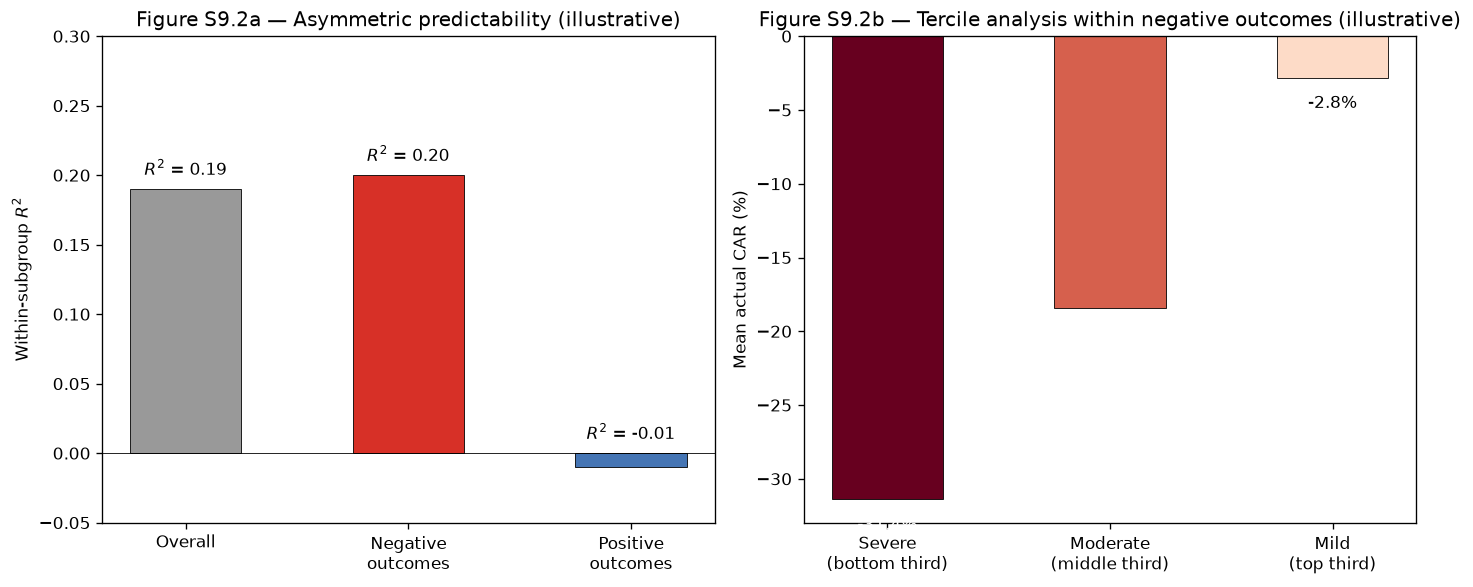

Illustrative, not measured. The pattern to take away is the asymmetry, not the numbers:
more predictive power for negative outcomes than for positive ones.
Within negatives, the model cleanly separates severe crashes from mild dips.


In [13]:
# Figure S9.2 — Asymmetric predictability: within-subgroup R-squared
# ILLUSTRATIVE. These R-squared and CAR values are invented to show the shape of the
# result. They are NOT measured on the shipped database — compare Figure S4.1, which is.
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))

# Left: within-subgroup R2
groups = ['Overall', 'Negative\noutcomes', 'Positive\noutcomes']
r2_vals = [0.19, 0.20, -0.01]
colors_r2 = ['#999999', '#d73027', '#4575b4']
bars = ax1.bar(groups, r2_vals, color=colors_r2, edgecolor='black', linewidth=0.5, width=0.5)
for bar, val in zip(bars, r2_vals):
    ax1.text(bar.get_x() + bar.get_width()/2, max(val, 0) + 0.01,
             f'$R^2$ = {val:.2f}', ha='center', fontsize=10)
ax1.axhline(y=0, color='black', linewidth=0.5)
ax1.set_ylabel('Within-subgroup $R^2$')
ax1.set_title('Figure S9.2a — Asymmetric predictability (illustrative)')
ax1.set_ylim(-0.05, 0.30)

# Right: tercile analysis within negative outcomes
terciles = ['Severe\n(bottom third)', 'Moderate\n(middle third)', 'Mild\n(top third)']
mean_cars = [-31.4, -18.4, -2.8]
bars2 = ax2.bar(terciles, mean_cars, color=['#67001f', '#d6604d', '#fddbc7'],
                edgecolor='black', linewidth=0.5, width=0.5)
for bar, val in zip(bars2, mean_cars):
    ax2.text(bar.get_x() + bar.get_width()/2, val - 1.2, f'{val:.1f}%',
             ha='center', va='top', fontsize=10, color='white' if val < -15 else 'black')
ax2.axhline(y=0, color='black', linewidth=0.5)
ax2.set_ylabel('Mean actual CAR (%)')
ax2.set_title('Figure S9.2b — Tercile analysis within negative outcomes (illustrative)')
plt.tight_layout()
plt.show()
print("Illustrative, not measured. The pattern to take away is the asymmetry, not the numbers:")
print("more predictive power for negative outcomes than for positive ones.")
print("Within negatives, the model cleanly separates severe crashes from mild dips.")

**Implications for scenario analysis.** If a predictive model demonstrates asymmetric predictability:

- **Downside scenarios** can be presented with narrower confidence ranges, because the model's predictions are more reliable.
- **Upside scenarios** should be presented with wider ranges and stronger caveats.
- This asymmetry is itself a useful finding to communicate: it tells the decision-maker that the analysis provides more reliable guidance for managing downside risk than for forecasting upside potential.

> **Exercise S9.1** | A general insurance company is considering entering a new market (cyber insurance). Construct a scenario analysis with three scenarios (optimistic, base, pessimistic) covering: (a) market growth, (b) loss experience, and (c) competitive dynamics. Assign probabilities. Discuss how this would feed into a decision about initial capital allocation.

> **Exercise S9.2** | A colleague presents a scenario analysis: Scenario A (50% probability, +\$10M NPV), Scenario B (30% probability, +\$2M NPV), Scenario C (20% probability, -\$15M NPV). Calculate the expected NPV. Explain why the expected NPV alone is insufficient for making a decision.

---
<a id="S10"></a>
## S10. Discriminator modelling

*Extends Chapter 6, Section 6.3.5 (Validating clustering outcomes)*

**Supports Q2b** — the technique that question names.

### Background

Chapter 6, Section 6.3.5 sets out three ways of validating a clustering: internal validation,
external validation, and manual validation. Each answers the question *"are these clusters any
good?"* None of them answers a different and equally practical question: *"what actually
distinguishes one cluster from another?"*

That second question becomes hard precisely when clustering is most useful. If you cluster on a
handful of interpretable variables, you can read the cluster centroids directly and describe each
group. If you cluster on high-dimensional text vectors — several thousand TF-IDF columns, or a
dense embedding — the centroid is a point in a space with no human-readable axes. The clusters may
be perfectly good and still tell you nothing you can put in a sentence.

**Discriminator modelling** solves this by turning the interpretation problem into a supervised
learning problem.

### Definition

Discriminator modelling fits a supervised classifier in which:

- the **response** is the cluster label produced by the unsupervised model; and
- the **predictors** are features in a space you can interpret.

You then discard the classifier's predictions entirely and keep only its **variable importance**.
Features the classifier relies on to tell the clusters apart are, by construction, the features that
distinguish those clusters.

The name is worth unpacking: the model *discriminates* between clusters, and its importance scores
are read as a description of the boundary rather than as a prediction about new data.

### What this technique is not

This is the step most often misunderstood, so it is worth stating directly.

**It is not a predictive model, and its accuracy is close to meaningless.** The labels you are
predicting were themselves produced by an algorithm applied to the same data. A high accuracy tells
you only that the clustering was internally consistent enough to be recoverable — not that it is
correct, useful, or generalisable. A classifier that recovers the clusters perfectly and a
classifier that recovers them adequately will usually give you the same top terms.

**It therefore requires no train/test split and no performance tuning.** You are describing a
dataset you already have, not estimating generalisation error. Default hyperparameters are
appropriate.

**It is descriptive, not causal.** A term with high importance distinguishes the clusters; it did
not cause them. Where two terms are strongly correlated, tree-based importance will often split the
credit between them arbitrarily, so a term's *absence* from the top of the list is weak evidence.

### Choosing the feature space

The predictors must be interpretable, which usually means they are **not** the features you
clustered on. A common pattern is:

1. cluster on reduced or embedded features, because that is what clusters well; then
2. fit the discriminator on the **pre-reduction** features, because those are the ones with names.

If you cluster on 50 principal components and then fit the discriminator on the same 50 components,
the output is a list of component numbers, which is no more interpretable than the centroid you
started with.

### Per-class importance

Standard impurity-based variable importance from a random forest is a **single global ranking**: it
tells you which features mattered for separating the clusters overall, not which features
characterise any particular cluster. For "top 10 terms for each cluster", that is the wrong shape.

The usual remedy is **one-vs-rest decomposition**: fit one binary classifier per cluster, each
predicting *"cluster k"* against *"everything else"*, and take each model's importance ranking as
that cluster's profile. With K clusters you fit K models. This is the same one-vs-rest idea used to
extend binary classifiers to multiclass problems (Chapter 5, Section 5.3), applied here for
interpretation rather than prediction.

### Implementation in Python

```python
from sklearn.ensemble import RandomForestClassifier
import numpy as np

# X_terms : the interpretable feature matrix (e.g. TF-IDF, before dimension reduction)
# labels  : cluster assignments from the unsupervised model
# vocab   : array of feature names, aligned with the columns of X_terms

top_terms = {}
for k in np.unique(labels):
    is_k = (labels == k).astype(int)          # one-vs-rest response
    rf = RandomForestClassifier(random_state=0)
    rf.fit(X_terms, is_k)
    order = np.argsort(rf.feature_importances_)[::-1][:10]
    top_terms[k] = vocab[order]
```

Two details matter. The response is rebuilt for each cluster, so `is_k` changes every iteration.
And `feature_importances_` is read from a model fitted to that binary problem — reading it from a
single multiclass model would return the global ranking this technique exists to avoid.

### Reading the output

A useful cluster profile is one you can turn into a sentence. If cluster 3's top terms are
*enrollment, terminated, futility, interim*, that is a readable description: trials stopped early.
If the top terms are *the, patients, study, results*, the vectorisation is doing the work rather
than the clustering, and the problem is upstream — revisit stop-word handling or term weighting
before interpreting further.

Terms that appear at the top of *every* cluster's list are not discriminating; they are frequent.
That is a signal to check the feature space, not a finding about the clusters.

### Worked example

The example below plants the three cluster vocabularies rather than estimating them, so the correct
profile is known before anything is fitted and the ways this technique misreads a corpus stay
visible. It departs from the snippet above in two respects: the classes are weighted, and impurity
importance is not trusted on its own.

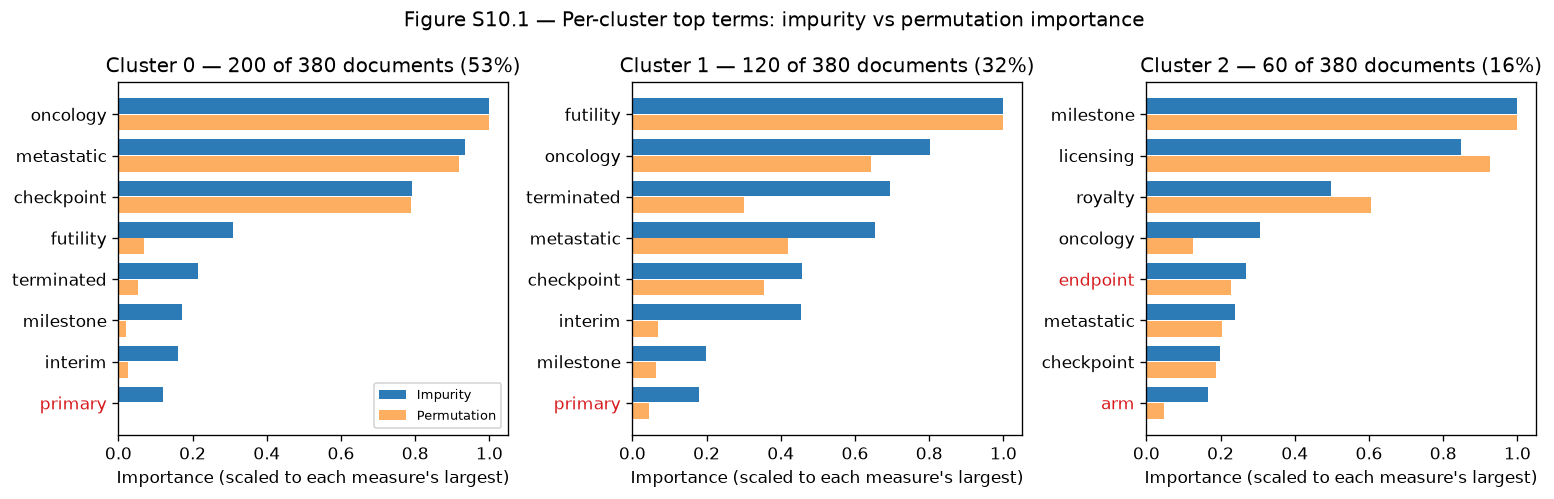

Cluster 0 top 10 by impurity: oncology, metastatic, checkpoint, futility, terminated, milestone, interim, primary, visit, dose
Cluster 1 top 10 by impurity: futility, oncology, terminated, metastatic, checkpoint, interim, milestone, primary, arm, endpoint
Cluster 2 top 10 by impurity: milestone, licensing, royalty, oncology, endpoint, metastatic, checkpoint, arm, blinded, randomised

Cluster 0: the 24 filler terms (red) discriminate nothing, yet take 36% of impurity importance and 1% of permutation importance.
Cluster 1: the 24 filler terms (red) discriminate nothing, yet take 41% of impurity importance and 3% of permutation importance.
Cluster 2: the 24 filler terms (red) discriminate nothing, yet take 47% of impurity importance and 20% of permutation importance.


In [14]:
# Figure S10.1 — One-vs-rest discriminators on a synthetic corpus (illustrative)
# SYNTHETIC. The three cluster vocabularies are planted, so the correct profile is known
# in advance and the ways the technique misreads it stay visible. No database required.
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance

rng = np.random.default_rng(7)
planted = {0: ['oncology', 'metastatic', 'checkpoint'],
           1: ['terminated', 'futility', 'interim'],
           2: ['licensing', 'milestone', 'royalty']}
filler = ('study patients phase trial results endpoint randomised data cohort dose '
          'safety efficacy primary secondary baseline arm blinded placebo sites visit '
          'protocol analysis population screening').split()
sizes = {0: 200, 1: 120, 2: 60}          # imbalanced, as cluster solutions usually are

docs, labels = [], []
for k, n in sizes.items():
    for _ in range(n):
        # a few distinctive terms, buried in twenty to sixty terms every document shares
        words = [t for t in planted[k] if rng.random() < 0.45]
        words += list(rng.choice(filler, size=rng.integers(20, 60)))
        docs.append(' '.join(words)); labels.append(k)
labels = np.array(labels)

vec = TfidfVectorizer()
X = vec.fit_transform(docs).toarray()
vocab = vec.get_feature_names_out()
is_filler = np.isin(vocab, filler)

fig, axes = plt.subplots(1, 3, figsize=(13, 4.2))
summary = []
for ax, k in zip(axes, sizes):
    y = (labels == k).astype(int)                        # one-vs-rest response
    rf = RandomForestClassifier(random_state=0, class_weight='balanced').fit(X, y)
    imp = rf.feature_importances_
    perm = np.clip(permutation_importance(rf, X, y, scoring='balanced_accuracy',
                                          n_repeats=10, random_state=0).importances_mean, 0, None)
    top = np.argsort(imp)[::-1][:8]                      # ranked by impurity
    pos = np.arange(len(top))[::-1]
    ax.barh(pos + 0.2, imp[top] / imp.max(), height=0.38, color='#2c7bb6', label='Impurity')
    ax.barh(pos - 0.2, perm[top] / max(perm.max(), 1e-12), height=0.38,
            color='#fdae61', label='Permutation')
    ax.set_yticks(pos); ax.set_yticklabels(vocab[top])
    for tick, t in zip(ax.get_yticklabels(), vocab[top]):
        tick.set_color('#d7191c' if t in filler else 'black')
    ax.set_xlabel("Importance (scaled to each measure's largest)")
    ax.set_title(f'Cluster {k} — {sizes[k]} of {len(labels)} documents ({sizes[k]/len(labels):.0%})')
    summary.append((k, vocab[np.argsort(imp)[::-1][:10]], imp[is_filler].sum(),
                    perm[is_filler].sum() / perm.sum()))
axes[0].legend(loc='lower right', fontsize=8)
fig.suptitle('Figure S10.1 — Per-cluster top terms: impurity vs permutation importance')
plt.tight_layout(); plt.show()

for k, terms, _, _ in summary:
    print(f'Cluster {k} top 10 by impurity: {", ".join(terms)}')
print()
for k, _, f_imp, f_perm in summary:
    print(f'Cluster {k}: the 24 filler terms (red) discriminate nothing, yet take '
          f'{f_imp:.0%} of impurity importance and {f_perm:.0%} of permutation importance.')

**Weight the classes.** One-vs-rest manufactures imbalance even from a balanced clustering: a
cluster holding a sixth of the corpus becomes a 16/84 problem. Left unweighted, the forest can drive
error down by attending to the majority side, and the importances then describe how it recognised
everything else. `class_weight='balanced'` costs nothing here, because there is no generalisation
to protect.

**Impurity importance is biased towards high-cardinality features.** A feature offers a candidate
split at every distinct value it takes, so features taking many values get more chances to reduce
impurity, including by chance. TF-IDF is the worst case for this: a term appearing in most documents
takes a different weight in nearly every one, while a genuinely distinctive term is zero almost
everywhere and takes a handful of values. In the run above the twenty-four filler terms — drawn
identically for every cluster, and so discriminating nothing — absorb between a third and a half of
all impurity importance.

**Cross-check with permutation importance.** Shuffling a column and re-scoring measures what the
model loses without that feature, so a term that supplied only convenient split points scores at or
near zero. Score it on balanced accuracy, for the same reason the classes are weighted.

Read the two together. A term is a finding when it ranks highly on impurity and survives
permutation; a term with a tall impurity bar and no permutation bar describes the feature space
rather than the cluster. The gap narrows for cluster 2, where sixty positive cases are few enough
for a fully grown forest to memorise and both measures are computed in sample: the smallest
cluster's profile is always the least reliable, and should be checked against exemplar documents.

### A cheaper first pass

Fitting one forest per cluster over a 20,000-column matrix is not the only way to get top terms, and it is the most expensive. Averaging TF-IDF within each cluster and subtracting the corpus mean ranks terms in a single pass, and a log-odds ratio with an informative prior does better still on rare terms. Neither tells you whether a cluster is *separable* — which is what the discriminator is actually for — so the cheap version is a first look, not a replacement. Run it first, then fit forests for the clusters whose profiles you want to test.

### Exercise S10.1

You fit a one-vs-rest discriminator for each of six clusters and find that one cluster's classifier
achieves 99% accuracy while another's achieves 71%. A colleague concludes that the first cluster is
"more real" than the second.

Explain whether this conclusion is supported, and what the two accuracies actually tell you.


---
<a id="appendix"></a>
## Appendix: Exercise answers

### Exercise S1.1

**Compute silhouette scores for K = 2 to 10 on the COVID-19 dataset.**

After fitting k-means for each value of K and computing the mean silhouette score, typical results might show that K = 3 maximises the silhouette score while the elbow method (WCSS) suggests K = 4 or K = 5. This disagreement is common: the silhouette score favours compact, well-separated clusters, while the elbow method measures total within-cluster variance.

Which to prefer depends on the business purpose. For grouping countries by pandemic response, K = 5 may produce more interpretable groups (e.g. 'strict lockdown early', 'moderate measures', 'delayed response', 'minimal intervention', 'island nations with border closures') even if the silhouette score is slightly lower. The silhouette score should inform the decision, not dictate it.

### Exercise S1.2

**Construct a silhouette plot and identify poorly defined clusters.**

The silhouette plot will show each observation's silhouette coefficient as a horizontal bar, grouped by cluster. Look for:

- **Clusters with many bars near or below zero**: these clusters contain observations that are ambiguously placed between clusters. These observations might represent countries with a mixed policy response that doesn't fit neatly into any single cluster.
- **Very small clusters**: may represent genuine outliers (e.g. countries with unique pandemic strategies) or artifacts of over-fitting the number of clusters.

The observations with the lowest silhouette scores should be examined individually. In a COVID-19 context, these might be countries that changed strategy mid-pandemic (e.g. Sweden initially pursuing herd immunity, then shifting) or countries with incomplete data.

### Exercise S2.1

**Explain why OLS might perform poorly with 500 observations and 200 features.**

With $p = 200$ features and $n = 500$ observations, the ratio $p/n = 0.4$ is high enough to cause problems for OLS:

1. **High variance**: OLS will fit the training data well (potentially $R^2 > 0.80$ in-sample) but generalise poorly because each coefficient is estimated from relatively few effective observations. Small perturbations in the data can produce large changes in coefficient estimates.

2. **Multicollinearity**: with 200 features, some are likely correlated. OLS cannot distinguish between correlated features and assigns unstable, inflated coefficients to each.

Ridge regression addresses this through the **bias-variance trade-off**: by adding a penalty $\lambda \sum \beta_j^2$, it deliberately introduces bias (shrinking coefficients toward zero) in exchange for a large reduction in variance. The net effect is typically better out-of-sample performance, because the reduction in variance outweighs the increase in bias.

### Exercise S2.2

**Compare OLS and ridge regression on the churn dataset.**

Using 'monthly charges' as the response and remaining features as predictors:

- OLS 5-fold cross-validated $R^2$ will typically be moderate (e.g. 0.70--0.80) because the churn dataset has relatively few features (~19) and many observations (~7,000), so the $p/n$ ratio is low.
- Ridge regression will produce similar or slightly better $R^2$ because the dataset does not severely need regularisation.

The key result (Hoerl & Kennard) is that there **exists** some $\lambda > 0$ whose expected MSE is lower than OLS's. That is a statement about a $\lambda$ you cannot observe: a $\lambda$ chosen by cross-validation can still lose to OLS on a given test set, through selection noise. The improvement is largest when $p$ is large relative to $n$ or when features are highly correlated. For this dataset, the improvement may be marginal.

### Exercise S3.1

**Interpret RMSE = \$12,400, MAE = \$6,200, $R^2$ = 0.35.**

- **RMSE = \$12,400**: on average, the model's predictions are approximately \$12,400 away from the actual claim amounts (in root-mean-square terms). This is the typical scale of prediction error.
- **MAE = \$6,200**: the *mean* absolute error — on average, predictions are about \$6,200 away from the actual claim amount, ignoring the direction of the error. (The median absolute error is a different statistic and is not reported here.)
- **$R^2$ = 0.35**: the model explains 35% of the variance in claim amounts. The remaining 65% is due to factors not captured by the model.

The RMSE being approximately double the MAE implies that the distribution of prediction errors is **right-skewed**: most errors are relatively small, but there are occasional large errors (likely from high-value claims) that inflate the RMSE. This is typical in insurance claim prediction, where the distribution of claim amounts is heavily right-skewed.

### Exercise S3.2

**Explain the drop from in-sample $R^2$ = 0.85 to cross-validated $R^2$ = 0.02.**

This is a textbook case of **overfitting**. With 200 features and 500 observations, the model has enough degrees of freedom to memorise patterns in the training data that do not generalise. The in-sample $R^2$ of 0.85 reflects this memorisation, while the cross-validated $R^2$ of 0.02 reveals that the model has almost no genuine predictive power.

Two approaches to address this:

1. **Regularisation**: use ridge regression, lasso, or elastic net to shrink coefficients and reduce model complexity. This directly addresses the high-$p$ problem.
2. **Dimensionality reduction**: apply PCA to reduce the 200 features to a smaller set of principal components before fitting the regression. This removes noise features and multicollinearity simultaneously.

### Exercise S3.3

**Perform quintile analysis on cross-validated predictions.**

Using the cross-validated predictions from Exercise S2.2:

1. Sort predictions and divide into quintiles.
2. Compute mean actual 'monthly charges' within each quintile.
3. The spread between Q5 and Q1 should be large (e.g. \$50--\$60), indicating that the model can distinguish between low-charge and high-charge customers.

Even if the overall $R^2$ is modest, the quintile spread demonstrates that the model has practical discriminatory power for ranking customers by expected charges.

### Exercise S4.1

**Design an ablation analysis for the churn model.**

Feature groups:
- **Group 1 (Demographics)**: gender, senior citizen, partner, dependents
- **Group 2 (Service usage)**: internet service, online security, online backup, device protection, tech support, streaming TV, streaming movies, phone service, multiple lines
- **Group 3 (Billing)**: contract type, payment method, paperless billing, monthly charges, total charges, tenure

Ablation conditions:
| Condition | Features included | What it tests |
|-----------|------------------|---------------|
| Baseline | All groups | Full model performance |
| Without demographics | Groups 2 + 3 | Are demographic features predictive beyond service usage? |
| Without service usage | Groups 1 + 3 | Do specific services matter, or is billing enough? |
| Without billing | Groups 1 + 2 | Are financial variables (charges, tenure, contract) the key drivers? |

Expected finding: billing features (especially tenure and contract type) will have the largest marginal contribution. Demographics alone will have limited predictive power. This tells the business that customer relationship length and contract structure are the primary drivers of churn, not demographics.

### Exercise S5.1

**Calculate proportional stratified sample sizes.**

Proportional allocation for 40 claims from 2,000:

| Category | Population | Proportion | Sample (proportional) |
|----------|-----------|------------|----------------------|
| Property | 1,200 | 60% | 24 |
| Motor | 500 | 25% | 10 |
| Liability | 200 | 10% | 4 |
| Professional indemnity | 100 | 5% | 2 |
| **Total** | **2,000** | **100%** | **40** |

Proportional allocation draws only two professional indemnity claims. A sample that size can detect only the crudest problem: if one claim in five in that category were mis-classified, the expected number of errors found is 0.4, so the single most likely outcome is that the audit finds none and reports the category as clean.

Where the purpose is auditing rather than estimating a population quantity, **disproportional allocation** — for example ten claims from each category — gives every stratum enough observations to be assessed. The cost is that the sample no longer mirrors the population, so it cannot be used directly to estimate an overall error rate without reweighting each stratum back to its population share.

The choice follows the purpose: use proportional allocation when the quantity of interest is a population total or average; use disproportional allocation when the purpose is to detect problems within each subgroup.

### Exercise S6.1

**Compare sentence embeddings and TF-IDF for semantic similarity.**

Using cosine similarity between two same-topic complaints (e.g. both about delayed baggage) and two different-topic complaints (e.g. baggage delay vs. medical emergency):

- **TF-IDF**: similarity will be driven by shared keywords. Two baggage-delay complaints may score high if they use similar words ('baggage', 'delayed', 'luggage'), but may score low if one uses different phrasing ('my suitcase never arrived' vs 'baggage was delayed 3 days'). TF-IDF cannot capture paraphrases.
- **Sentence embeddings**: will produce high similarity for same-topic complaints even with different wording, because the model understands that 'suitcase never arrived' and 'baggage was delayed' convey similar meaning.

Sentence embeddings better capture semantic similarity, especially for paraphrased or varied-vocabulary text. TF-IDF is better for keyword-level matching (e.g. 'find all complaints mentioning the word refund').

### Exercise S7.1

**Explain why general-purpose models might misinterpret 'the trial was terminated early'.**

In general English, 'terminated' typically has negative connotations (e.g. 'employment was terminated', 'the contract was terminated'). A general-purpose model would likely assign negative sentiment to this phrase.

In a clinical trial context, 'terminated early' is ambiguous:
- It could mean the trial was **stopped for futility** (negative — the drug didn't work).
- It could mean the trial was **stopped early for efficacy** (positive — the drug worked so well that it was unethical to continue giving placebo).
- It could mean the trial was **stopped for safety** (negative — unacceptable adverse events).

A domain-specific model like BioBERT or ClinicalBERT, trained on clinical literature, would recognise this ambiguity and not default to negative sentiment. It would use surrounding context (e.g. 'terminated early due to overwhelming efficacy' vs 'terminated early due to safety concerns') to determine the correct interpretation.

### Exercise S8.1

**Score 'Despite the significant impairment charge, the company's operating cash flow improved materially.'**

**(a) General-purpose (TextBlob)**: the net polarity is close to neutral, and its sign is not the interesting part — it depends on the tool and on which lexicon version you have, so run it rather than predict it. What matters is which words are scored. A general-purpose lexicon assigns sentiment to 'significant' and to 'charge', neither of which carries sentiment in a financial register, and those two misreadings pull in opposite directions. A near-neutral total can therefore sit on top of several individually wrong judgements — which is why a net score alone will not tell you the tool is unsuitable.

**(b) Loughran-McDonald**:
- 'impairment' → **Negative** (financial loss term)
- 'improved' → **Positive** (favourable outcome)
- All other words → **Neutral** (including 'significant', 'charge', 'operating', 'cash', 'flow', 'materially')

The LM dictionary correctly identifies that only 'impairment' and 'improved' carry financial sentiment. The net result (1 negative, 1 positive) suggests a balanced/mixed sentiment, which is arguably the correct interpretation: the company took a negative accounting charge but generated positive cash flow.

The general-purpose tool misclassifies 'charge' and 'significant' as sentiment-bearing, producing a less accurate assessment of financial sentiment. This is precisely the problem the Loughran-McDonald dictionary was built to solve.

### Exercise S9.1

**Construct a scenario analysis for cyber insurance market entry.**

| Scenario | Probability | Market growth | Loss experience | Competition |
|----------|------------|---------------|-----------------|-------------|
| Optimistic | 25% | 25% p.a. growth; cyber security spending increases | Loss ratio 45%; few large events | Limited new entrants; strong pricing power |
| Base case | 50% | 15% p.a. growth; steady adoption | Loss ratio 65%; one major event per year | Moderate competition; adequate pricing |
| Pessimistic | 25% | 5% p.a. growth; economic slowdown | Loss ratio 95%; systemic event (e.g. widespread ransomware) | Aggressive pricing by well-capitalised competitors |

Capital allocation decision: the expected combined ratio across scenarios is approximately 70%, suggesting the market is profitable in expectation. However, the pessimistic scenario (25% probability, 95% loss ratio) could generate significant losses. Initial capital allocation should be sized to survive the pessimistic scenario for at least two years, with a staged entry that allows the company to scale back if early loss experience exceeds the base case.

### Exercise S9.2

**Calculate expected NPV and explain its limitations.**

Expected NPV = $0.50 \times \$10M + 0.30 \times \$2M + 0.20 \times (-\$15M)$ = $\$5M + \$0.6M - \$3M$ = **+\$2.6M**

The expected NPV is positive, but it is **insufficient** for several reasons:

1. **Downside risk**: there is a 20% chance of losing \$15M. If this loss would threaten the company's solvency or breach regulatory capital requirements, the project should be rejected regardless of the positive expected value.
2. **Asymmetry**: the worst-case loss (\$15M) is larger than the best-case gain (\$10M). The expected value does not capture this asymmetry.
3. **Risk appetite**: the decision depends on the organisation's risk tolerance. A risk-averse decision-maker might reject a project with 20% probability of a \$15M loss, even with a positive expected value.

Additional useful information from the scenario analysis: the probability of a negative outcome (20%), the maximum loss (\$15M), and whether any risk mitigation is available (e.g. can the project be staged so that Scenario C can be detected early and losses limited?).

### Exercise S10.1

**A one-vs-rest discriminator reaches 99% accuracy for one cluster and 71% for another. Is the first
cluster "more real"?**

The conclusion is not supported as stated, though the observation is informative.

Both figures are in-sample recoveries of labels that the clustering algorithm itself produced, so
neither is evidence that a cluster corresponds to anything real in the world. A cluster carved out
of noise can still be recovered perfectly if it occupies a distinct region of the feature space —
recoverability and validity are different properties.

What the difference does tell you is how **separable** each cluster is in the interpretable feature
space. A 99% score suggests the cluster is characterised by a small number of distinctive terms, so
its top-10 profile is likely to be readable and stable. A 71% score suggests the cluster overlaps
its neighbours, so its profile should be treated as indicative and cross-checked against manual
inspection of exemplar members (Chapter 6, Section 6.3.5, manual validation).

Note also the class imbalance created by one-vs-rest. If a cluster holds 4% of observations, a
classifier that predicts "not in this cluster" every time scores 96% while identifying nothing. Any
accuracy figure here should be read against that baseline, which is another reason the technique's
value lies in its importance rankings rather than its performance.